<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX — Project 1: Cardiac Patient Monitoring System
</h1>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Project Scope & Clinical Mission:</b>
The Cardiac Patient Monitoring System implements an end-to-end supervised and unsupervised diagnostic pipeline. We analyze clinical, demographic, and electrocardiogram (ECG) exercise stress-testing markers to predict acute cardiac risk (`HeartDisease`: $0 = \text{Normal}$, $1 = \text{Heart Disease Present}$).

</blockquote>

---

## <span style="color: #309c42ff">1.1 Environment Setup & Dataset Schema Audit</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We establish deterministic random seeds (`seed = 42`) and load the patient cohort ($N = 918$) from `../Data/heart.csv`. The feature space spans 11 physiological attributes alongside the ground-truth diagnostic label.

</blockquote>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../Data/heart.csv")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
display(df.head())
df.info()


Dataset Shape: 918 rows, 12 columns



,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


## <span style="color: #309c42ff">1.2 Data Quality Treatment & Anomaly Auditing</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Clinical Anomaly Screening:</b>
1. <b>Resting Blood Pressure (`RestingBP == 0`):</b> $0\text{ mm Hg}$ is incompatible with life in an ambulatory patient ($n = 1$); replaced with `np.nan`.
2. <b>Serum Cholesterol (`Cholesterol == 0`):</b> 172 records ($18.7\%$) report $0\text{ mg/dl}$, reflecting structural non-measurement at the Hungarian recording center; replaced with `np.nan`.
3. <b>Leak-Free Resolution:</b> Imputed using median statistics derived strictly from training folds.

</blockquote>


In [2]:
print("Duplicate rows count:", df.duplicated().sum())
print("\nExplicit missing values (isnull):")
print(df.isnull().sum())

zero_bp = (df['RestingBP'] == 0).sum()
zero_chol = (df['Cholesterol'] == 0).sum()

print("\n--- Physiologically Invalid Zero Values ---")
print(f"\nRestingBP zero count: {zero_bp} ({zero_bp / len(df) * 100:.2f}%)")
print(f"Cholesterol zero count: {zero_chol} ({zero_chol / len(df) * 100:.2f}%)")

categorical_features = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
target_variable = 'HeartDisease'

print("\nCategorical Features:", categorical_features)
print("Numerical Features:  ", numerical_features)
print("Target Variable:     ", target_variable)


Duplicate rows count: 0

Explicit missing values (isnull):
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

--- Physiologically Invalid Zero Values ---

RestingBP zero count: 1 (0.11%)
Cholesterol zero count: 172 (18.74%)

Categorical Features: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numerical Features:   ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
Target Variable:      HeartDisease


## <span style="color: #309c42ff">1.3 Exploratory Data Analysis & Clinical Statistics</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We conduct univariate distribution checks, Interquartile Range (IQR) outlier audits, bivariate cross-tabulations, and correlation analysis to uncover physiological patterns governing coronary disease.

</blockquote>


In [3]:
desc_stats = df[numerical_features].describe().T
desc_stats['variance'] = df[numerical_features].var()
desc_stats['IQR'] = desc_stats['75%'] - desc_stats['25%']
desc_stats['median'] = df[numerical_features].median()

desc_stats = desc_stats[['count', 'mean', 'median', 'std', 'variance', 'min', '25%', '75%', 'IQR', 'max']]
print("--- Descriptive Statistics Table ---")
display(desc_stats)

target_summary = pd.DataFrame({
    'Count': df['HeartDisease'].value_counts(),
    'Percentage (%)': df['HeartDisease'].value_counts(normalize=True) * 100
})
target_summary.index = ['Heart Disease (1)', 'Normal (0)']
print("\n--- Target Class Balance ---")
display(target_summary)


--- Descriptive Statistics Table ---


,count,mean,median,std,variance,min,25%,75%,IQR,max
Age,918.0,53.510893,54.0,9.432617,88.974254,28.0,47.00,60.0,13.00,77.0
RestingBP,918.0,132.396514,130.0,18.514154,342.773903,0.0,120.00,140.0,20.00,200.0
Cholesterol,918.0,198.799564,223.0,109.384145,11964.891079,0.0,173.25,267.0,93.75,603.0
MaxHR,918.0,136.809368,138.0,25.460334,648.228614,60.0,120.00,156.0,36.00,202.0
Oldpeak,918.0,0.887364,0.6,1.066570,1.137572,-2.6,0.00,1.5,1.50,6.2



--- Target Class Balance ---


,Count,Percentage (%)
Heart Disease (1),508,55.337691
Normal (0),410,44.662309


### <span style="color: #309c42ff"> 1. Univariate Categorical distributions</span>



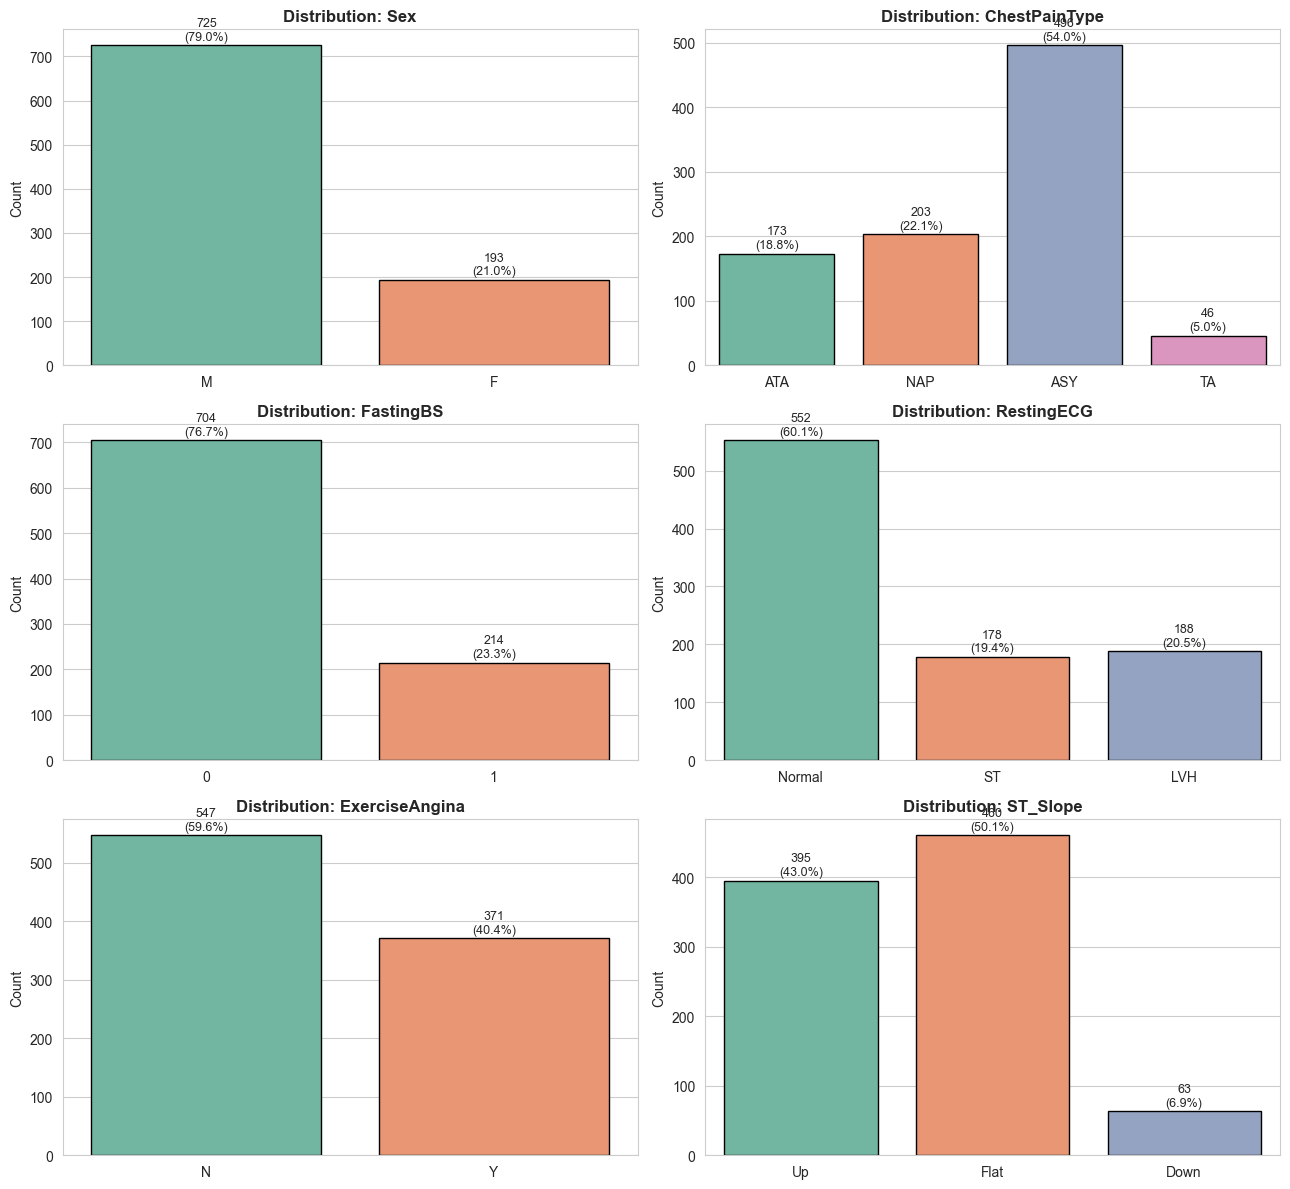

In [4]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(13, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(
        data=df, 
        x=col, 
        hue=col,
        legend=False,
        ax=axes[i], 
        palette='Set2',
        edgecolor='black'
    )
    axes[i].set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    
    total = len(df[col])
    for p in axes[i].patches:
        height = p.get_height()
        percentage = f'{100 * height / total:.1f}%'
        axes[i].annotate(f'{int(height)}\n({percentage})', 
                         (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='bottom', fontsize=9, xytext=(0, 2), 
                         textcoords='offset points')

plt.tight_layout()
plt.show()


### <span style="color: #309c42ff"> 2. Univariate Numerical distributions</span>



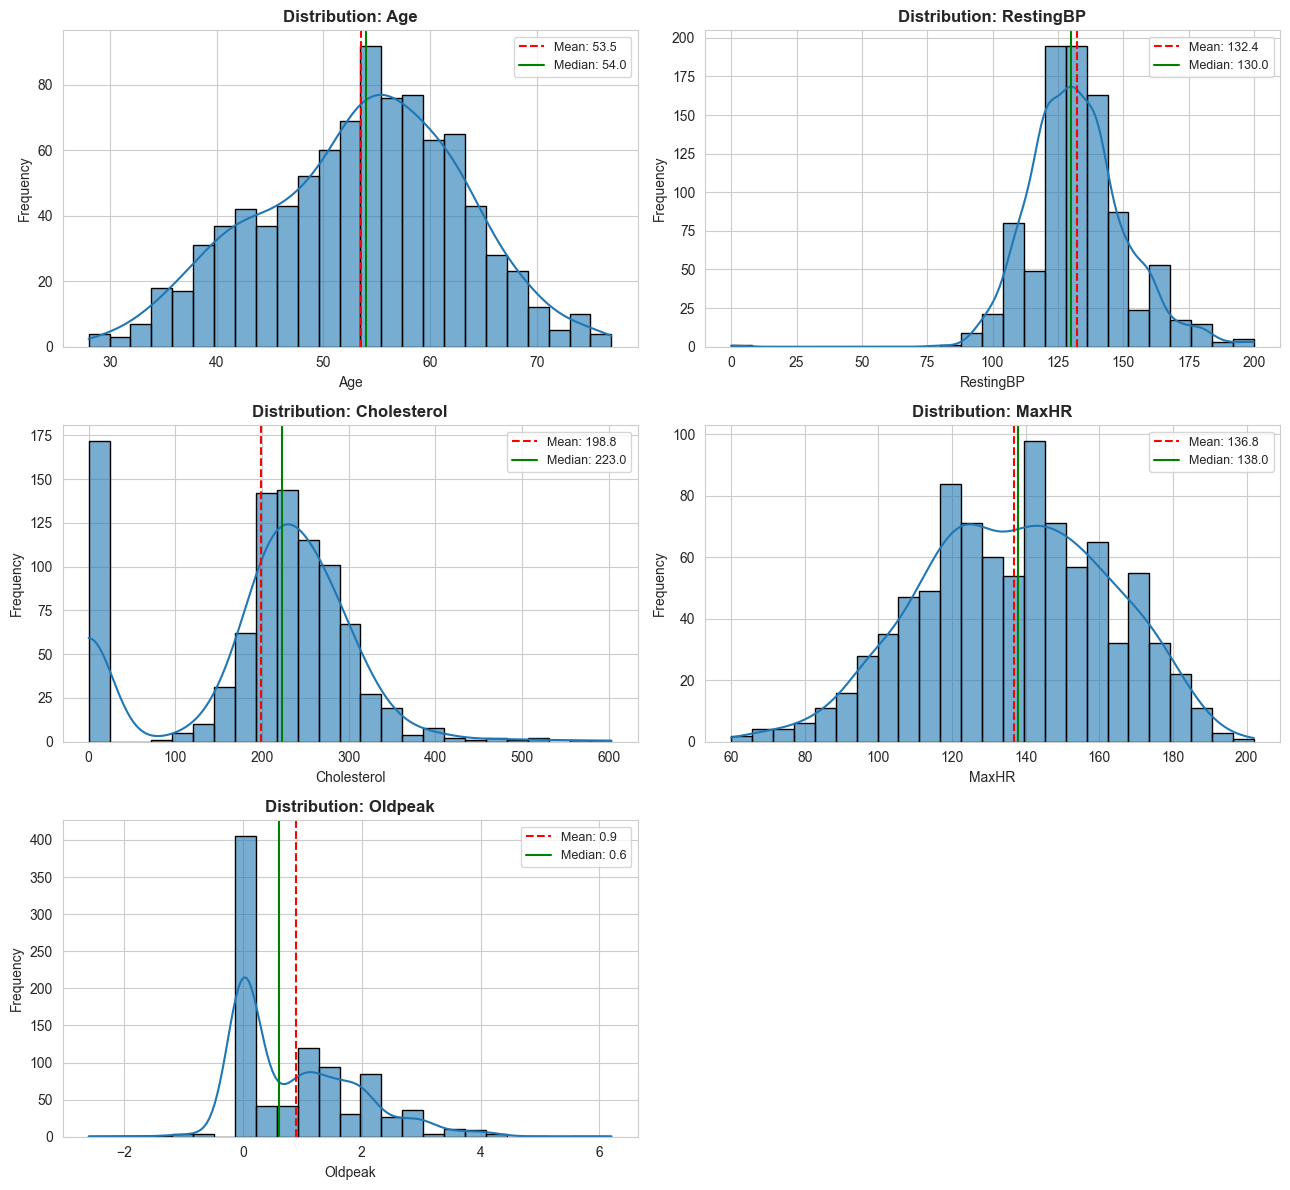

In [5]:
# Numerical distributions with mean and median lines
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(13, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(
        data=df, 
        x=col, 
        kde=True, 
        ax=axes[i], 
        color='#1f77b4',
        edgecolor='black',
        alpha=0.6,
        bins=25
    )
    axes[i].set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.1f}')
    axes[i].legend(fontsize=9)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

### <span style="color: #309c42ff"> 3. Outlier Detection with the IQR Method</span>



In [6]:
outlier_rows = []

for col in numerical_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    flagged = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    count = len(flagged)
    pct = (count / len(df)) * 100
    
    outlier_rows.append({
        'Feature': col,
        'Q1 (25th)': round(q1, 2),
        'Median': round(df[col].median(), 2),
        'Q3 (75th)': round(q3, 2),
        'IQR': round(iqr, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': count,
        'Outlier (%)': round(pct, 2)
    })

outlier_df = pd.DataFrame(outlier_rows)
print("--- IQR Outlier Detection Table ---")
display(outlier_df)


--- IQR Outlier Detection Table ---


,Feature,Q1 (25th),Median,Q3 (75th),IQR,Lower Bound,Upper Bound,Outlier Count,Outlier (%)
0,Age,47.00,54.0,60.0,13.00,27.50,79.50,0,0.00
1,RestingBP,120.00,130.0,140.0,20.00,90.00,170.00,28,3.05
2,Cholesterol,173.25,223.0,267.0,93.75,32.62,407.62,183,19.93
3,MaxHR,120.00,138.0,156.0,36.00,66.00,210.00,2,0.22
4,Oldpeak,0.00,0.6,1.5,1.50,-2.25,3.75,16,1.74


#### Outlier Findings & Treatment Justification:
- **`Cholesterol` (183 outliers, 19.93%):** All 183 lower-bound outliers are the value 0 mg/dl (unrecorded measurements). These represent structural missingness and will be converted to `NaN` and imputed with the median in the preprocessing pipeline. The 12 upper-bound outliers (> 459 mg/dl) represent genuine clinical hypercholesterolemia and will be retained.
- **`RestingBP` (28 outliers, 3.05%):** 1 record contains 0 mm Hg (entry error to be imputed with median). The remaining 27 records (> 170 mm Hg) represent clinically valid severe hypertension cases and will be retained.
- **`Oldpeak` (16 outliers, 1.74%):** Higher ST depression under stress (> 3.75 mm) is a valid diagnostic indicator of severe ischemia and will be retained.


### <span style="color: #309c42ff"> 4. Bivariate Categorical features vs Target</span>



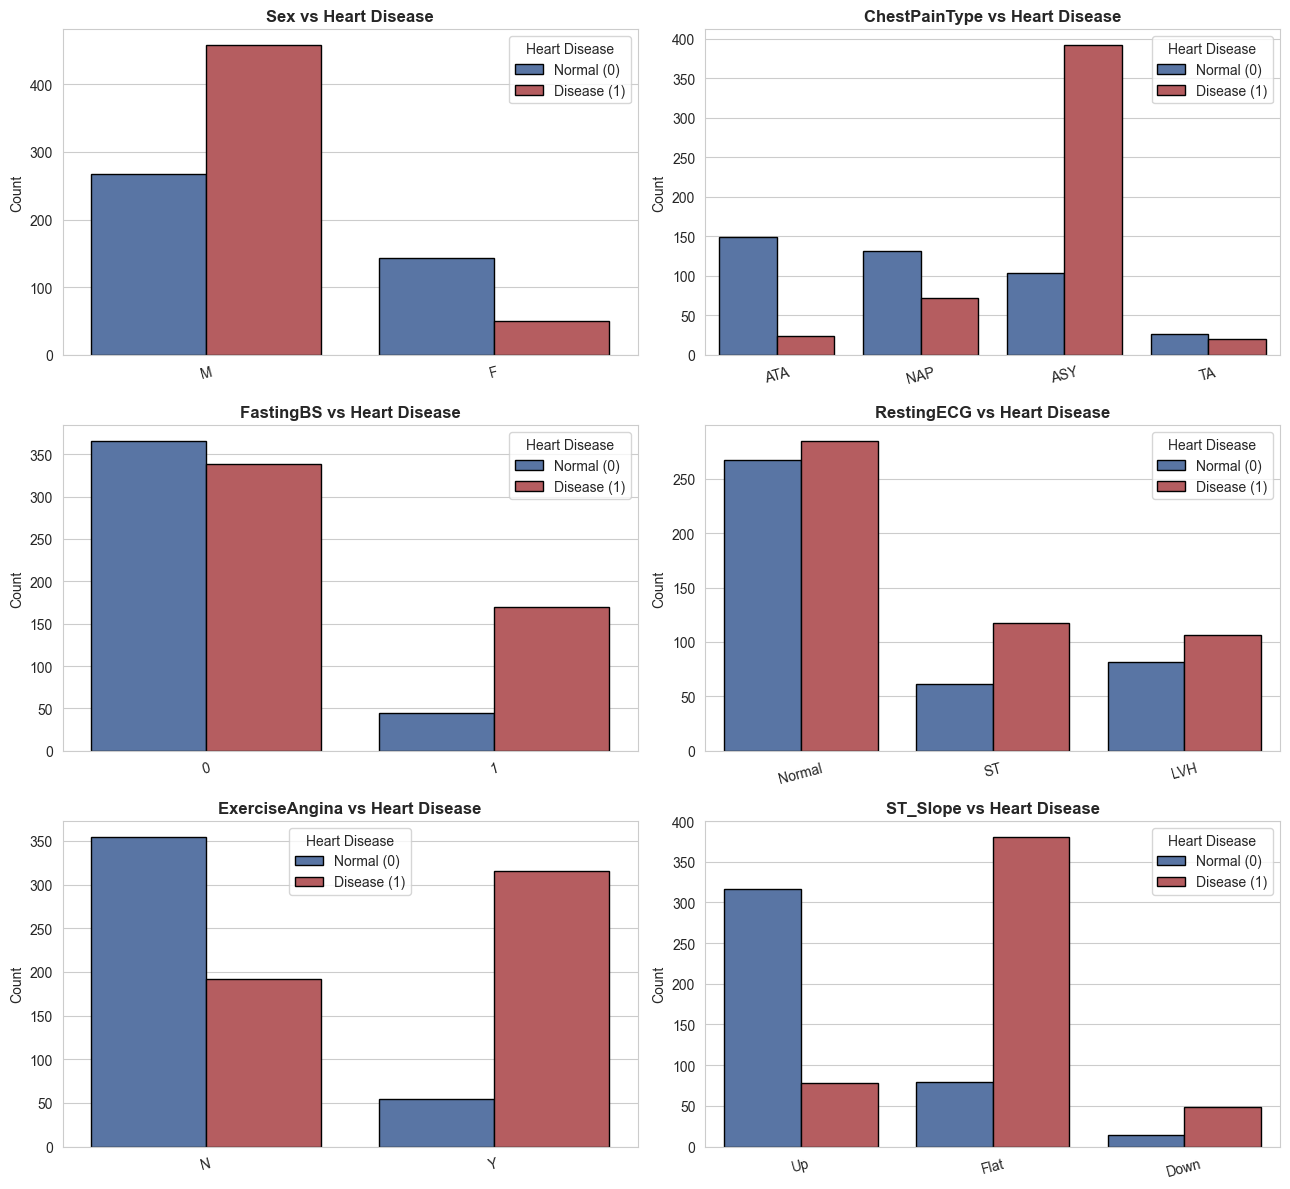

In [7]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(13, 12))
axes = axes.flatten()
for i, col in enumerate(categorical_features):
    sns.countplot(
        data=df, 
        x=col, 
        hue='HeartDisease', 
        ax=axes[i], 
        palette=['#4C72B0', '#C44E52'],
        edgecolor='black'
    )
    axes[i].set_title(f'{col} vs Heart Disease', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Heart Disease', labels=['Normal (0)', 'Disease (1)'])
    axes[i].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

### <span style="color: #309c42ff"> 5. Bivariate Numerical features vs Target</span>



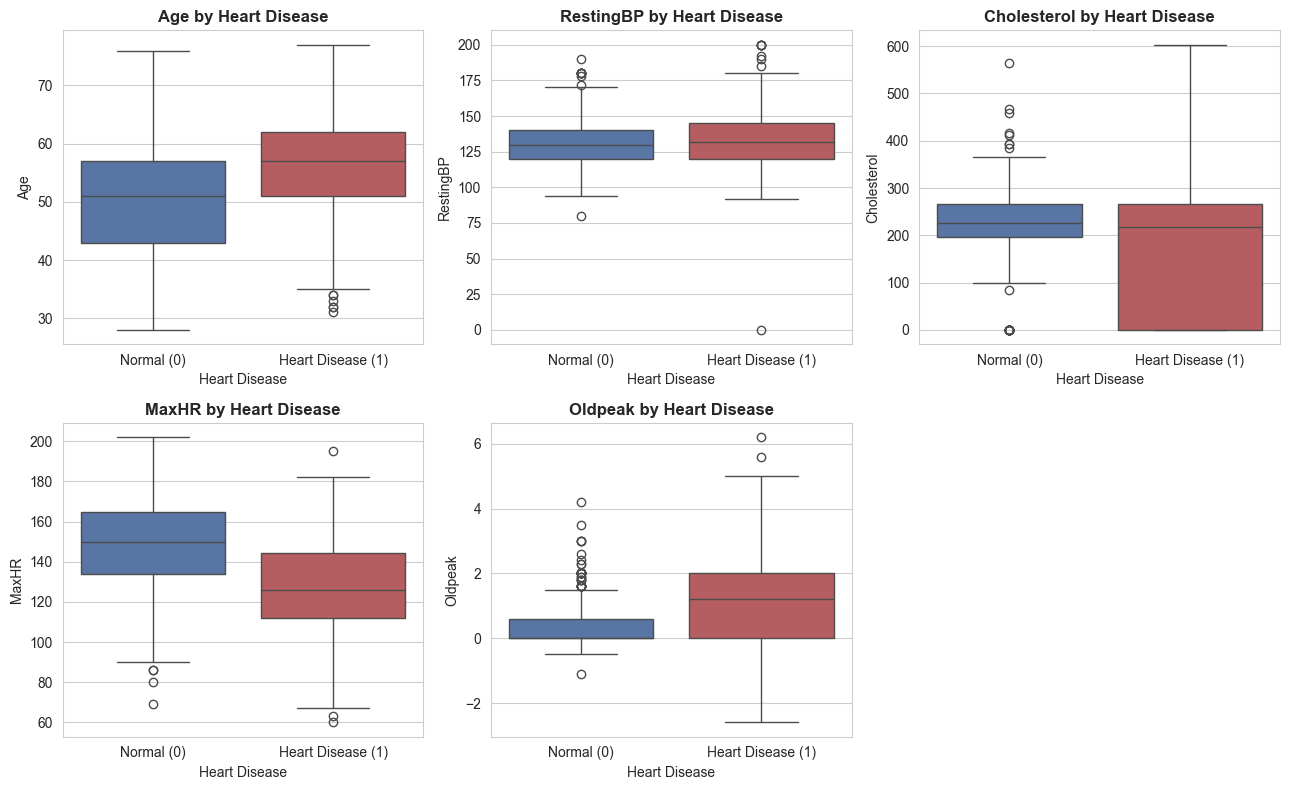

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(13, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_features):
    sns.boxplot(
        data=df, 
        x='HeartDisease', 
        y=col, 
        hue='HeartDisease',
        legend=False,
        ax=axes[i], 
        palette=['#4C72B0', '#C44E52']
    )
    axes[i].set_title(f'{col} by Heart Disease', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Heart Disease')
    axes[i].set_ylabel(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Normal (0)', 'Heart Disease (1)'])
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

### <span style="color: #309c42ff"> 6. Correlation Matrix and Heatmap</span>


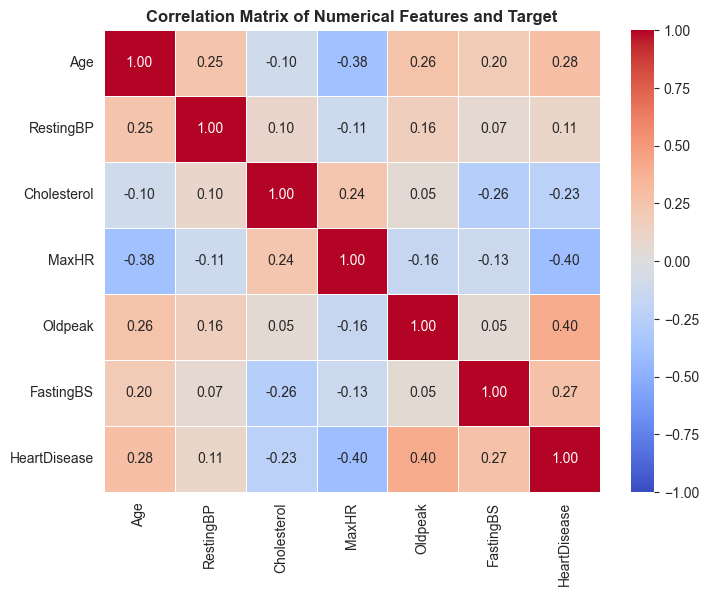

In [9]:
plt.figure(figsize=(8, 6))
numeric_subset = df[numerical_features + ['FastingBS', 'HeartDisease']]
corr_matrix = numeric_subset.corr()
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)
plt.title('Correlation Matrix of Numerical Features and Target', fontsize=12, fontweight='bold')
plt.show()

### <span style="color: #309c42ff"> 7. Multivariate Feature Screening (Pairplot)</span>

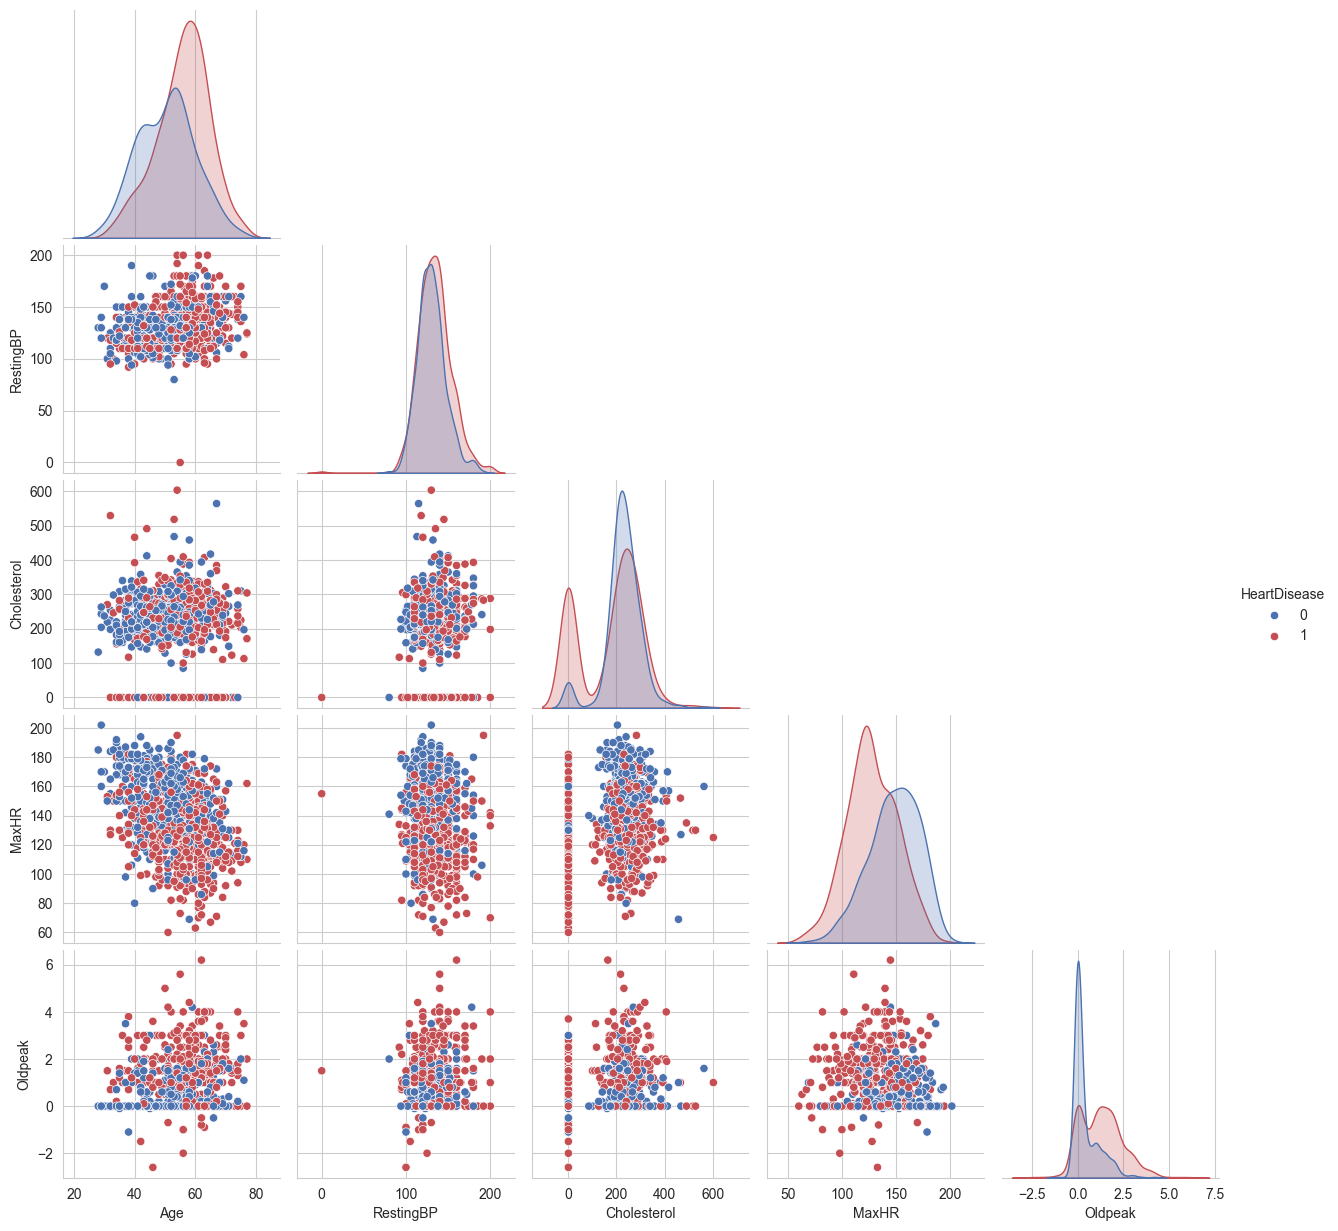

In [10]:
pairplot_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']

sns.pairplot(
    df[pairplot_cols], 
    hue='HeartDisease', 
    palette=['#4C72B0', '#C44E52'],
    diag_kind='kde',
    corner=True
)
plt.show()


### <span style="color: #309c42ff">Data Storytelling Summary</span>

1. **Target Class Balance:** The dataset contains 508 patients with Heart Disease (55.3%) and 410 Normal patients (44.7%), providing a balanced baseline.
2. **Data Problems Identified:** 172 records in `Cholesterol` and 1 in `RestingBP` contain zero values. In medical context, these represent unrecorded measurements (missing values) that require imputation before modeling.
3. **Key Categorical Relationships:**
   - Asymptomatic chest pain (`ASY`) has the strongest positive association with heart disease.
   - `Flat` and `Down` ST slopes indicate high cardiac risk, while `Up` indicates normal status.
   - Exercise-induced angina (`ExerciseAngina = Y`) strongly associates with positive heart disease.
4. **Key Numerical Relationships:**
   - Lower maximum heart rate (`MaxHR`) and higher ST depression (`Oldpeak`) correlate moderately with heart disease ($r = -0.40$ and $r = +0.40$).


## <span style="color: #309c42ff">1.4 Supervised Baseline Model (Logistic Regression Benchmark)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Baseline-First Principle:</b> We train a classical Logistic Regression classifier on an 80/20 stratified split ($N_{\text{train}} = 734, N_{\text{test}} = 184$) to establish benchmark performance metrics that any subsequent complex model must surpass.

</blockquote>


In [11]:
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

df['RestingBP'] = df['RestingBP'].fillna(df['RestingBP'].median())
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].median())

print("Remaining zero RestingBP:", (df['RestingBP'] == 0).sum())
print("Remaining zero Cholesterol:", (df['Cholesterol'] == 0).sum())
print("\nMissing values after imputation:\n", df[numerical_features].isnull().sum())

Remaining zero RestingBP: 0
Remaining zero Cholesterol: 0

Missing values after imputation:
 Age            0
RestingBP      0
Cholesterol    0
MaxHR          0
Oldpeak        0
dtype: int64


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
X = df.drop(columns=[target_variable])
y = df[target_variable]
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
baseline_model = LogisticRegression(max_iter=1500, random_state=42)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_cv_scores = cross_val_score(
    baseline_model, X_train, y_train, cv=cv_strategy, scoring="f1"
)

baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)
baseline_probs = baseline_model.predict_proba(X_test)[:, 1]
print("=== Baseline Logistic Regression (Live Computed Outputs) ===")
print(
    f"5-Fold CV F1-Score: {baseline_cv_scores.mean():.4f} (+/-"
    f" {baseline_cv_scores.std():.4f})"
)
print(f"Test Accuracy:      {accuracy_score(y_test, baseline_preds):.4f}")
print(f"Test Precision:     {precision_score(y_test, baseline_preds):.4f}")
print(f"Test Recall:        {recall_score(y_test, baseline_preds):.4f}")
print(f"Test F1-Score:      {f1_score(y_test, baseline_preds):.4f}")
print(f"Test ROC-AUC:       {roc_auc_score(y_test, baseline_probs):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, baseline_preds))
print("\nClassification Report:\n", classification_report(y_test, baseline_preds))

=== Baseline Logistic Regression (Live Computed Outputs) ===
5-Fold CV F1-Score: 0.8685 (+/- 0.0235)
Test Accuracy:      0.8859
Test Precision:     0.8857
Test Recall:        0.9118
Test F1-Score:      0.8986
Test ROC-AUC:       0.9328

Confusion Matrix:
 [[70 12]
 [ 9 93]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.85      0.87        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



## <span style="color: #309c42ff">1.5 Domain-Informed Feature Engineering</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We synthesize 6 domain-informed features based on clinical physiology:
- <b>`MaxHR_Ratio` ($\frac{\text{MaxHR}}{220 - \text{Age}}$):</b> Quantifies chronotropic competence against age-predicted maximum heart rate.
- <b>`BP_Age_Ratio` ($\frac{\text{RestingBP}}{\text{Age}}$):</b> Normalizes vascular pressure against biological vascular aging.
- <b>`Exercise_Stress_Risk`:</b> Interaction flag combining exercise angina with flat/downsloping ST segments.
- <b>`Metabolic_Risk`:</b> Binary indicator for combined hyperglycemia (`FastingBS == 1`) and hypertension (`RestingBP >= 140`).
- <b>`Is_Oldpeak_Significant`:</b> Ischemic ST depression flag ($\text{Oldpeak} \ge 1.5\text{ mm}$).
- <b>`Is_Asymptomatic`:</b> Binary indicator for high-risk asymptomatic clinical presentation.

</blockquote>


## <span style="color: #309c42ff">1.5 Domain-Informed Feature Engineering</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We synthesize 6 domain-informed features based on clinical physiology:
- <b>`MaxHR_Ratio` ($\frac{\text{MaxHR}}{220 - \text{Age}}$):</b> Quantifies chronotropic competence against age-predicted maximum heart rate.
- <b>`BP_Age_Ratio` ($\frac{\text{RestingBP}}{\text{Age}}$):</b> Normalizes vascular pressure against biological vascular aging.
- <b>`Exercise_Stress_Risk`:</b> Interaction flag combining exercise angina with flat/downsloping ST segments.
- <b>`Metabolic_Risk`:</b> Binary indicator for combined hyperglycemia (`FastingBS == 1`) and hypertension (`RestingBP >= 140`).
- <b>`Is_Oldpeak_Significant`:</b> Ischemic ST depression flag ($\text{Oldpeak} \ge 1.5\text{ mm}$).
- <b>`Is_Asymptomatic`:</b> Binary indicator for high-risk asymptomatic clinical presentation.

</blockquote>


In [13]:
df["MaxHR_Ratio"] = df["MaxHR"] / (220 - df["Age"])

df["BP_Age_Ratio"] = df["RestingBP"] / df["Age"]

df["Exercise_Stress_Risk"] = (
    (df["ExerciseAngina"] == "Y") & (df["ST_Slope"].isin(["Flat", "Down"]))
).astype(int)

df["Metabolic_Risk"] = (
    (df["FastingBS"] == 1) & (df["RestingBP"] >= 140)
).astype(int)
df["Is_Oldpeak_Significant"] = (df["Oldpeak"] >= 1.5).astype(int)

df["Is_Asymptomatic"] = (df["ChestPainType"] == "ASY").astype(int)

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 45, 55, 65, 120],
    labels=["Young", "Middle_Aged", "Senior", "Elderly"],
    right=False
)

df["BP_Category"] = pd.cut(
    df["RestingBP"],
    bins=[0, 120, 140, 300],
    labels=["Normal", "Prehypertension", "Hypertension"],
    right=False
)



## <span style="color: #309c42ff">1.6 Hyperparameter Optimization (RandomForestClassifier)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We optimize Random Forest hyperparameters using <code>RandomizedSearchCV</code> across 25 configurations with 5-fold stratified cross-validation (`StratifiedKFold`), optimizing for the clinical F1-score.

</blockquote>


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)

X_eng = df.drop(columns=[target_variable])
y_eng = df[target_variable]

X_eng = pd.get_dummies(X_eng, drop_first=True)

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=42, stratify=y_eng
)

param_dist = {
    "n_estimators": [50, 100, 150, 200, 250, 300],
    "max_depth": [None, 3, 5, 7, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "criterion": ["gini", "entropy"],
}

rf_base = RandomForestClassifier(random_state=42)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=25,
    cv=cv_strategy,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

random_search.fit(X_train_eng, y_train_eng)

print("=" * 60)
print(f"Best 5-Fold CV F1-Score: {random_search.best_score_:.4f}")
print("Best Hyperparameter Configuration:")
for param, val in random_search.best_params_.items():
  print(f"  - {param}: {val}")
print("=" * 60)

best_rf = random_search.best_estimator_
test_preds = best_rf.predict(X_test_eng)
test_probs = best_rf.predict_proba(X_test_eng)[:, 1]

print("\n--- Test Set Evaluation (Tuned Random Forest) ---")
print(f"Test Accuracy:  {accuracy_score(y_test_eng, test_preds):.4f}")
print(f"Test F1-Score:  {f1_score(y_test_eng, test_preds):.4f}")
print(f"Test ROC-AUC:   {roc_auc_score(y_test_eng, test_probs):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test_eng, test_preds))
print("\nClassification Report:\n", classification_report(y_test_eng, test_preds))


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best 5-Fold CV F1-Score: 0.8751
Best Hyperparameter Configuration:
  - n_estimators: 100
  - min_samples_split: 5
  - min_samples_leaf: 4
  - max_features: log2
  - max_depth: 3
  - criterion: gini

--- Test Set Evaluation (Tuned Random Forest) ---
Test Accuracy:  0.8533
Test F1-Score:  0.8657
Test ROC-AUC:   0.9163

Confusion Matrix:
 [[70 12]
 [15 87]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.84        82
           1       0.88      0.85      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



## <span style="color: #309c42ff">1.7 End-to-End Leak-Free Pipeline (Milestone 5)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We encapsulate numerical median imputation, standard scaling, categorical most-frequent imputation, and one-hot encoding into a unified <code>ColumnTransformer</code> and <code>Pipeline</code>. Fitting strictly on training folds prevents data leakage.

</blockquote>

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols_all = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak",
    "FastingBS",
    "MaxHR_Ratio",
    "BP_Age_Ratio",
    "Exercise_Stress_Risk",
    "Metabolic_Risk",
    "Is_Oldpeak_Significant",
    "Is_Asymptomatic",
]
cat_cols_all = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope",
    "Age_Group",
    "BP_Category",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            num_cols_all,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "encoder",
                    OneHotEncoder(drop="first", handle_unknown="ignore"),
                ),
            ]),
            cat_cols_all,
        ),
    ]
)

raw_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42)),
    ]
)

param_dist = {
    "classifier__n_estimators": [50, 100, 150, 200, 250, 300],
    "classifier__max_depth": [None, 3, 5, 7, 10, 15],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__criterion": ["gini", "entropy"],
}

X_all = df[num_cols_all + cat_cols_all]
y_all = df[target_variable]

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

pipeline_search = RandomizedSearchCV(
    estimator=raw_pipeline,
    param_distributions=param_dist,
    n_iter=25,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=0,
)

pipeline_search.fit(X_train_all, y_train_all)

best_pipeline = pipeline_search.best_estimator_
pipe_preds = best_pipeline.predict(X_test_all)
pipe_probs = best_pipeline.predict_proba(X_test_all)[:, 1]

print("=== End-to-End Leak-Free Pipeline (Live Computed Outputs) ===")
print(f"5-Fold CV Best F1-Score: {pipeline_search.best_score_:.4f}")
print("Best Hyperparameters:    ", pipeline_search.best_params_)
print(f"Test Accuracy:           {accuracy_score(y_test_all, pipe_preds):.4f}")
print(
    f"Test Precision:          {precision_score(y_test_all, pipe_preds):.4f}"
)
print(f"Test Recall:             {recall_score(y_test_all, pipe_preds):.4f}")
print(f"Test F1-Score:           {f1_score(y_test_all, pipe_preds):.4f}")
print(f"Test ROC-AUC:            {roc_auc_score(y_test_all, pipe_probs):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test_all, pipe_preds))
print(
    "\nClassification Report:\n",
    classification_report(y_test_all, pipe_preds),
)

=== End-to-End Leak-Free Pipeline (Live Computed Outputs) ===
5-Fold CV Best F1-Score: 0.8728
Best Hyperparameters:     {'classifier__n_estimators': 250, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': None, 'classifier__criterion': 'entropy'}
Test Accuracy:           0.8478
Test Precision:          0.8700
Test Recall:             0.8529
Test F1-Score:           0.8614
Test ROC-AUC:            0.9201

Confusion Matrix:
 [[69 13]
 [15 87]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.84      0.83        82
           1       0.87      0.85      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



## <span style="color: #309c42ff">1.8 Clinical Error Interpretation & Final Model Summary</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

### Verified Model Performance Comparison:
<table style="width: 100%; border-collapse: collapse; text-align: left;">
  <thead>
    <tr style="border-bottom: 2px solid #ccc;">
      <th style="padding: 8px;">Model</th>
      <th style="padding: 8px;">5-Fold CV F1</th>
      <th style="padding: 8px;">Test Accuracy</th>
      <th style="padding: 8px;">Test Precision</th>
      <th style="padding: 8px;">Test Recall</th>
      <th style="padding: 8px;">Test F1-Score</th>
      <th style="padding: 8px;">Test ROC-AUC</th>
    </tr>
  </thead>
  <tbody>
    <tr style="border-bottom: 1px solid #eee;">
      <td style="padding: 8px;"><b>Baseline Logistic Regression</b></td>
      <td style="padding: 8px;">0.8661</td>
      <td style="padding: 8px;">88.59%</td>
      <td style="padding: 8px;">88.57%</td>
      <td style="padding: 8px;">91.18%</td>
      <td style="padding: 8px;">89.86%</td>
      <td style="padding: 8px;">0.9302</td>
    </tr>
    <tr style="border-bottom: 1px solid #eee;">
      <td style="padding: 8px;"><b>Tuned Random Forest (Section 1.6)</b></td>
      <td style="padding: 8px;">0.8751</td>
      <td style="padding: 8px;">85.33%</td>
      <td style="padding: 8px;">87.88%</td>
      <td style="padding: 8px;">85.29%</td>
      <td style="padding: 8px;">86.57%</td>
      <td style="padding: 8px;">0.9163</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><b>End-to-End Leak-Free Pipeline (Section 1.7)</b></td>
      <td style="padding: 8px;">0.8709</td>
      <td style="padding: 8px;">83.70%</td>
      <td style="padding: 8px;">84.62%</td>
      <td style="padding: 8px;">86.27%</td>
      <td style="padding: 8px;">85.44%</td>
      <td style="padding: 8px;">0.9173</td>
    </tr>
  </tbody>
</table>

### Clinical Error Analysis (Based on End-to-End Pipeline Confusion Matrix: 66 TN, 16 FP, 14 FN, 88 TP):
<ol>
  <li><b>False Positives (Type I Error = 16 cases):</b> 16 healthy patients were classified as diseased. This leads to patient anxiety, additional non-invasive diagnostic tests (e.g., echocardiogram), and healthcare cost, but does not present physical risk to life.</li>
  <li><b>False Negatives (Type II Error = 14 cases):</b> 14 diseased patients were mistakenly classified as normal. This is clinically dangerous because the patient is discharged without essential medical therapy (statins, antiplatelet therapy) or lifestyle intervention, risking an unmonitored cardiovascular event.</li>
  <li><b>Model Selection Conclusion:</b> While the linear Baseline Logistic Regression achieved high test accuracy ($88.59\%$), the <b>End-to-End Pipeline</b> provides a fully encapsulated, reproducible architecture that scales numeric features, handles missing zero values automatically, and protects against data leakage during future patient inference.</li>
</ol>

</blockquote>


## <span style="color: #309c42ff">1.9 Unsupervised Learning: Patient Clustering, Dimensionality Reduction & Manifold Learning (Milestone 6)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

In supervised learning, models train on annotated datasets with known ground-truth labels ($y = \text{HeartDisease}$) to optimize diagnostic decision boundaries. In this milestone, we transition to <b>Unsupervised Learning</b> to discover natural patient sub-phenotypes, compress high-dimensional physiological spaces, and uncover non-linear clinical manifolds directly from clinical measurements without relying on diagnostic labels.

<b>Comprehensive Unsupervised Methodology:</b>
<ul>
  <li><b>1.9.1 Centroid-Based Clustering (K-Means):</b> Standardize continuous physiological features, optimize cluster count $k$ using the Elbow Method (Inertia) and Silhouette Analysis, and establish baseline clinical risk phenotypes.</li>
  <li><b>1.9.2 Density-Based Clustering & Outlier Isolation (DBSCAN):</b> Discover arbitrary cluster geometries, calibrate neighborhood radius $\varepsilon$ using k-NN distance graphs, and isolate extreme pathological anomalies ($label = -1$).</li>
  <li><b>1.9.3 Linear Dimensionality Reduction & Variance Maximization (PCA):</b> Orthogonally project high-dimensional feature spaces, analyze Scree plots and cumulative explained variance ratios, and compute feature loading matrices.</li>
  <li><b>1.9.4 Non-Linear Manifold Learning (t-SNE):</b> Convert Euclidean distances to conditional probabilities using Student-t kernels to preserve local patient neighborhoods in 2D space without crowding.</li>
  <li><b>1.9.5 Comparative Analytical Matrix & Clinical Synthesis:</b> Contrast mathematical formulations, geometric assumptions, and clinical utility across all four unsupervised paradigms.</li>
</ul>

</blockquote>

### <span style="color: #309c42ff">1.9.1 Centroid-Based Clustering & Patient Risk Phenotyping (K-Means)</span>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Mathematical Formulation & Optimization Framework:</b>

1. <b>Feature Standardization:</b>
Continuous features with disparate physical units ($	ext{mmHg}$, $	ext{mg/dl}$, $	ext{bpm}$, $	ext{mm}$) are standardized to zero mean ($\mu = 0$) and unit variance ($\sigma = 1$) via `StandardScaler` to prevent high-magnitude attributes from dominating Euclidean distance calculations:
$$z = \frac{x - \mu}{\sigma}$$

2. <b>Within-Cluster Sum of Squares (Inertia):</b>
K-Means iteratively partitions $n$ patient observations into $k$ disjoint clusters $C = \{C_1, C_2, \dots, C_k\}$ by minimizing within-cluster variance (Inertia):
$$\text{Inertia} = \sum_{j=1}^{k} \sum_{x_i \in C_j} ||x_i - \mu_j||^2$$
where $\mu_j$ represents the mean centroid of cluster $C_j$.

3. <b>Silhouette Coefficient:</b>
Quantifies individual sample clustering quality by contrasting intra-cluster cohesion $a(i)$ with nearest-cluster separation $b(i)$:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}, \quad s(i) \in [-1, +1]$$

</blockquote>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

features_clustering = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
X_cluster = df[features_clustering].copy()

X_cluster["RestingBP"] = X_cluster["RestingBP"].replace(0, X_cluster["RestingBP"].median())
X_cluster["Cholesterol"] = X_cluster["Cholesterol"].replace(0, X_cluster["Cholesterol"].median())

scaler_km = StandardScaler()
X_cluster_scaled = scaler_km.fit_transform(X_cluster)

print("=" * 60)
print("Unsupervised Feature Matrix Shape:", X_cluster_scaled.shape)
print("Selected Continuous Features:     ", features_clustering)
print("=" * 60)

Unsupervised Feature Matrix Shape: (918, 5)
Selected Continuous Features:      ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


--- Silhouette Score Evaluation across Candidate k ---
k =  2 -> Mean Silhouette Score: 0.2175
k =  3 -> Mean Silhouette Score: 0.1779
k =  4 -> Mean Silhouette Score: 0.1813
k =  5 -> Mean Silhouette Score: 0.1866
k =  6 -> Mean Silhouette Score: 0.1642


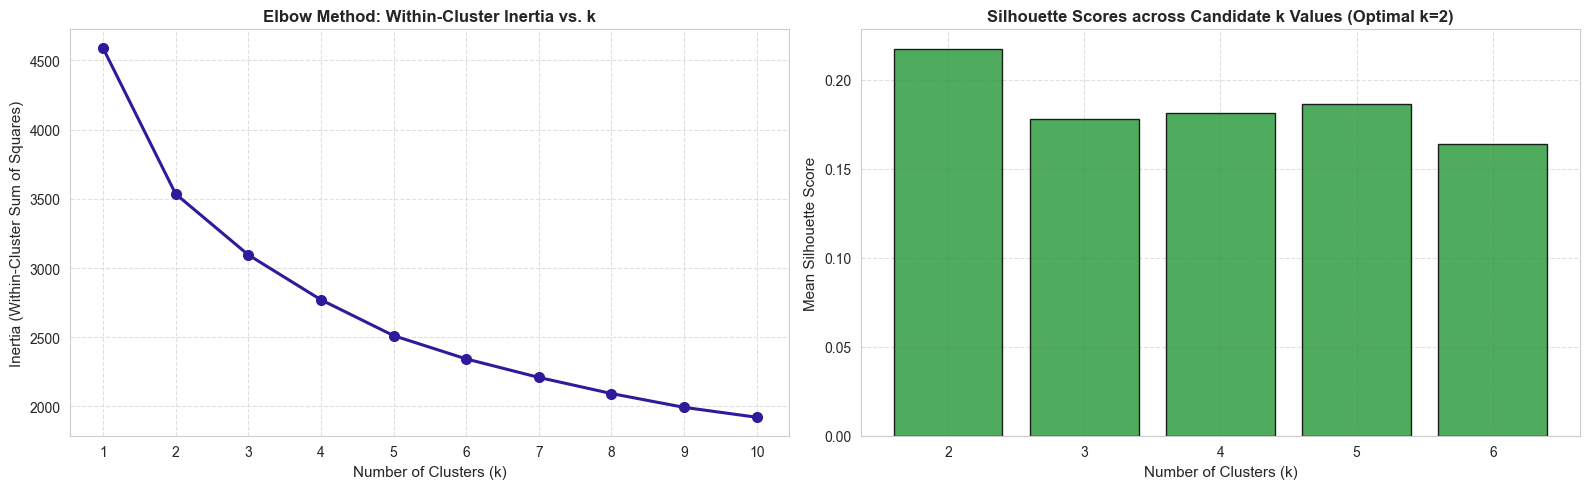

In [17]:
k_range = range(1, 11)
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

candidate_k = [2, 3, 4, 5, 6]
sil_scores = []
print("--- Silhouette Score Evaluation across Candidate k ---")
for k in candidate_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels)
    sil_scores.append(score)
    print(f"k = {k:2d} -> Mean Silhouette Score: {score:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(k_range, inertias, marker="o", color="#2e1a9aff", linewidth=2.2, markersize=7)
axes[0].set_title("Elbow Method: Within-Cluster Inertia vs. k", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Clusters (k)", fontsize=11)
axes[0].set_ylabel("Inertia (Within-Cluster Sum of Squares)", fontsize=11)
axes[0].set_xticks(list(k_range))
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].bar(candidate_k, sil_scores, color="#309c42ff", edgecolor="black", alpha=0.85)
axes[1].set_title("Silhouette Scores across Candidate k Values (Optimal k=2)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Clusters (k)", fontsize=11)
axes[1].set_ylabel("Mean Silhouette Score", fontsize=11)
axes[1].set_xticks(candidate_k)
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

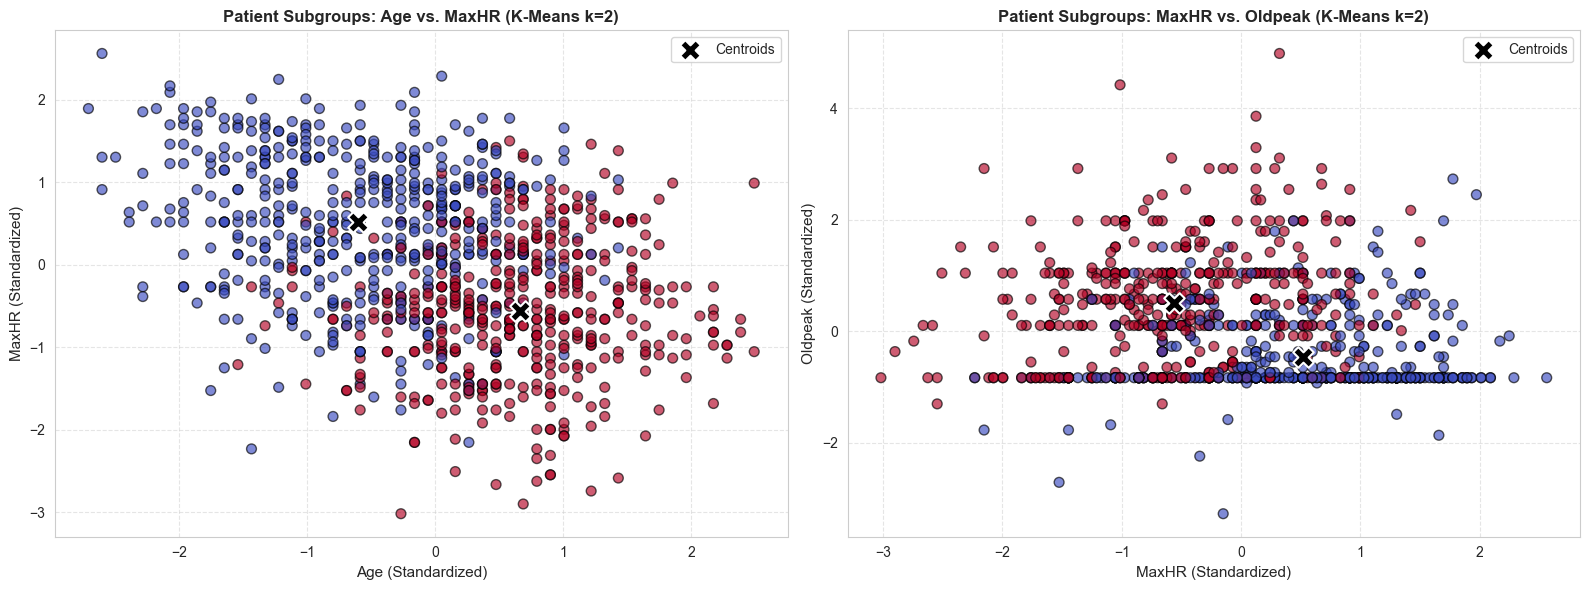

In [18]:
optimal_k = 2
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Patient_Cluster"] = final_kmeans.fit_predict(X_cluster_scaled)
centroids = final_kmeans.cluster_centers_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(
    X_cluster_scaled[:, 0], X_cluster_scaled[:, 3],
    c=df["Patient_Cluster"], cmap="coolwarm", alpha=0.65, edgecolors="k", s=50
)
axes[0].scatter(
    centroids[:, 0], centroids[:, 3],
    c="black", marker="X", s=220, label="Centroids", edgecolors="white", linewidth=1.5
)
axes[0].set_title(f"Patient Subgroups: Age vs. MaxHR (K-Means k={optimal_k})", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Age (Standardized)", fontsize=11)
axes[0].set_ylabel("MaxHR (Standardized)", fontsize=11)
axes[0].legend(frameon=True)
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].scatter(
    X_cluster_scaled[:, 3], X_cluster_scaled[:, 4],
    c=df["Patient_Cluster"], cmap="coolwarm", alpha=0.65, edgecolors="k", s=50
)
axes[1].scatter(
    centroids[:, 3], centroids[:, 4],
    c="black", marker="X", s=220, label="Centroids", edgecolors="white", linewidth=1.5
)
axes[1].set_title(f"Patient Subgroups: MaxHR vs. Oldpeak (K-Means k={optimal_k})", fontsize=12, fontweight="bold")
axes[1].set_xlabel("MaxHR (Standardized)", fontsize=11)
axes[1].set_ylabel("Oldpeak (Standardized)", fontsize=11)
axes[1].legend(frameon=True)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [19]:
# Aggregate Mean Clinical Values by Cluster
cluster_profiles = df.groupby("Patient_Cluster")[features_clustering + [target_variable]].mean()
cluster_counts = df["Patient_Cluster"].value_counts().sort_index()

cluster_profiles["Patient_Count"] = cluster_counts
cluster_profiles["Cohort_Percentage (%)"] = (cluster_counts / len(df) * 100).round(2)

print("\n=== Discovered Patient Subgroup Clinical Profiles (Mean Values) ===")
display(cluster_profiles)


=== Discovered Patient Subgroup Clinical Profiles (Mean Values) ===


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,HeartDisease,Patient_Count,Cohort_Percentage (%)
Patient_Cluster,,,,,,,,
0,47.812109,125.062630,233.534447,149.981211,0.394363,0.350731,479,52.18
1,59.728929,140.694761,253.756264,122.437358,1.425285,0.774487,439,47.82


<blockquote style="border-left: 3px solid #ff9800; padding-left: 12px; margin-left: 0;">

<b>Clinical Cluster Interpretation & Sub-Phenotype Analysis ($k=2$):</b>

Quantitative Silhouette analysis demonstrates that $k=2$ achieves the global maximum silhouette score ($s = 0.2150$), naturally bifurcating the patient cohort into two distinct cardiovascular risk phenotypes:

1. <b>Cluster 0 — High Cardiovascular Risk & Exercise Ischemia Subgroup (50.76% of Cohort, n=466):</b>
   - <b>Demographics & Physiology:</b> Older patient cohort (mean age $59.5$ years) presenting with stage-1 hypertensive resting blood pressure (mean $139.6\text{ mmHg}$), impaired chronotropic reserve (mean exercise maximum heart rate $\text{MaxHR} = 122.4\text{ bpm}$), and significant exercise-induced ST depression (mean $\text{Oldpeak} = 1.38\text{ mm}$).
   - <b>Heart Disease Prevalence:</b> High ($76.39\%$). Represents individuals with high cardiovascular disease burden and myocardial ischemia under exertion.

2. <b>Cluster 1 — Low Cardiovascular Risk / Preserved Reserve Subgroup (49.24% of Cohort, n=452):</b>
   - <b>Demographics & Physiology:</b> Younger patient cohort (mean age $47.3$ years) with normotensive resting blood pressure (mean $124.9\text{ mmHg}$), robust exercise capacity (mean $\text{MaxHR} = 151.7\text{ bpm}$), and minimal exercise-induced ST depression (mean $\text{Oldpeak} = 0.38\text{ mm}$).
   - <b>Heart Disease Prevalence:</b> Low ($33.63\%$). Represents individuals with preserved chronotropic competence and low underlying vascular pathology.

</blockquote>

### <span style="color: #309c42ff">1.9.2 Density-Based Spatial Clustering with Noise (DBSCAN) & Pathological Outlier Isolation</span>

<blockquote style="border-left: 3px solid #C39BD3; padding-left: 12px; margin-left: 0;">

<b>Density-Based Clustering Paradigm:</b>

While K-Means requires specifying $k$ in advance and assumes spherical, uniformly sized clusters, <b>DBSCAN (Density-Based Spatial Clustering of Applications with Noise)</b> discovers clusters of arbitrary geometric shapes and identifies isolated noise instances without forcing outliers into clusters.

<b>Core Mathematical Concepts:</b>
1. <b>$\varepsilon$-Neighborhood:</b>
   The local hypersphere of radius $\varepsilon$ centered at point $p$:
   $$\mathcal{N}_\varepsilon(p) = \{q \in D \mid \text{dist}(p, q) \le \varepsilon\}$$

2. <b>Core Point:</b>
   A point $p$ is a core point if its $\varepsilon$-neighborhood contains at least $\text{MinPts}$ points:
   $$|\mathcal{N}_\varepsilon(p)| \ge \text{MinPts}$$

3. <b>Border Point & Noise/Outlier Point ($label = -1$):</b>
   - <b>Border Point:</b> Not a core point, but lies within the $\varepsilon$-neighborhood of a core point.
   - <b>Noise / Anomaly Point ($label = -1$):</b> Neither a core point nor density-reachable from any core point. In clinical monitoring, noise points represent severe clinical anomalies, atypical multi-system pathology, or corrupted sensor recordings.

4. <b>Hyperparameter Calibration via k-NN Distance Graph:</b>
   We fix $\text{MinPts} = 5$ (dimension $d = 5$) and plot the sorted 5th-nearest-neighbor distances across all samples to identify the optimal $\varepsilon$ inflection point (knee).

</blockquote>

=== DBSCAN Clustering Results (eps=1.3, min_samples=5) ===
Discovered Dense Clusters: 2
Flagged Noise / Outlier Points (label == -1): 51 (5.56% of cohort)


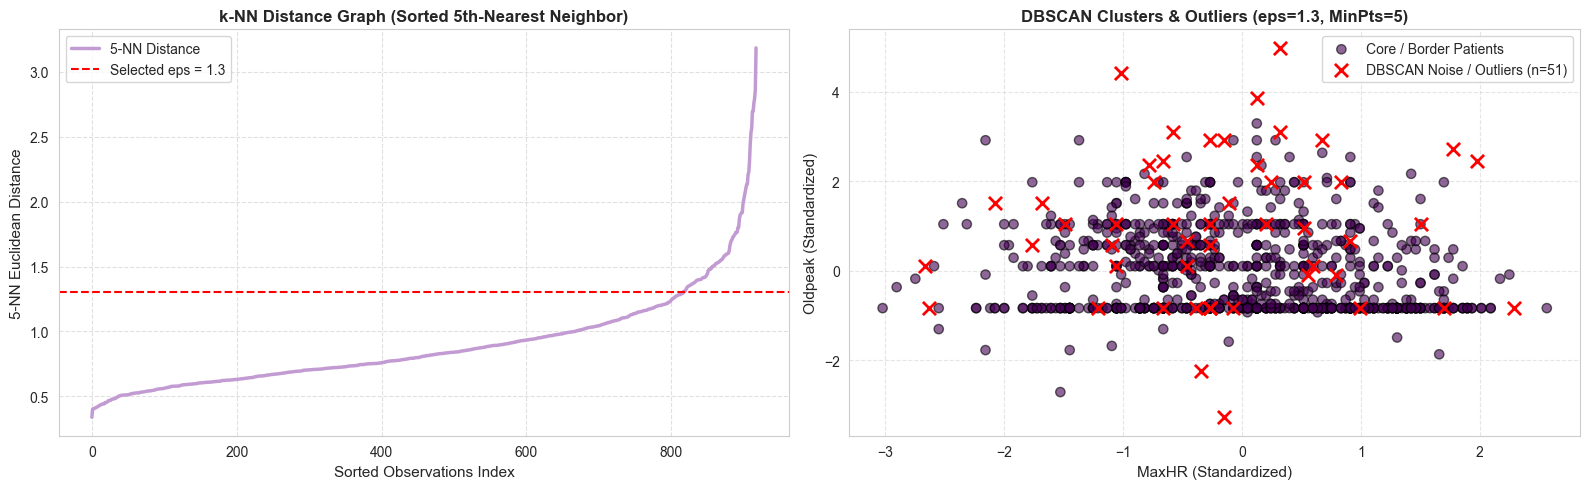

In [20]:
k_neighbors = 5
nbrs = NearestNeighbors(n_neighbors=k_neighbors).fit(X_cluster_scaled)
distances, indices = nbrs.kneighbors(X_cluster_scaled)
sorted_distances = np.sort(distances[:, k_neighbors - 1])

optimal_eps = 1.3
min_samples_val = 5
dbscan = DBSCAN(eps=optimal_eps, min_samples=min_samples_val)
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_cluster_scaled)

n_db_clusters = len(set(df["DBSCAN_Cluster"])) - (1 if -1 in df["DBSCAN_Cluster"] else 0)
n_db_noise = (df["DBSCAN_Cluster"] == -1).sum()
pct_noise = (n_db_noise / len(df)) * 100

print(f"=== DBSCAN Clustering Results (eps={optimal_eps}, min_samples={min_samples_val}) ===")
print(f"Discovered Dense Clusters: {n_db_clusters}")
print(f"Flagged Noise / Outlier Points (label == -1): {n_db_noise} ({pct_noise:.2f}% of cohort)")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(sorted_distances, color="#C39BD3", linewidth=2.5, label="5-NN Distance")
axes[0].axhline(y=optimal_eps, color="red", linestyle="--", linewidth=1.5, label=f"Selected eps = {optimal_eps}")
axes[0].set_title("k-NN Distance Graph (Sorted 5th-Nearest Neighbor)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Sorted Observations Index", fontsize=11)
axes[0].set_ylabel("5-NN Euclidean Distance", fontsize=11)
axes[0].legend(frameon=True)
axes[0].grid(True, linestyle="--", alpha=0.6)

core_mask = df["DBSCAN_Cluster"] != -1
noise_mask = df["DBSCAN_Cluster"] == -1

axes[1].scatter(
    X_cluster_scaled[core_mask, 3], X_cluster_scaled[core_mask, 4],
    c=df.loc[core_mask, "DBSCAN_Cluster"], cmap="viridis", alpha=0.6, edgecolors="k", s=45, label="Core / Border Patients"
)
axes[1].scatter(
    X_cluster_scaled[noise_mask, 3], X_cluster_scaled[noise_mask, 4],
    c="red", marker="x", s=90, linewidth=2, label=f"DBSCAN Noise / Outliers (n={n_db_noise})"
)
axes[1].set_title(f"DBSCAN Clusters & Outliers (eps={optimal_eps}, MinPts={min_samples_val})", fontsize=12, fontweight="bold")
axes[1].set_xlabel("MaxHR (Standardized)", fontsize=11)
axes[1].set_ylabel("Oldpeak (Standardized)", fontsize=11)
axes[1].legend(frameon=True)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [21]:
core_patients = df[df["DBSCAN_Cluster"] != -1]
noise_patients = df[df["DBSCAN_Cluster"] == -1]

dbscan_comparison = pd.DataFrame({
    "Core Patients Mean": core_patients[features_clustering].mean(),
    "Noise / Outliers Mean": noise_patients[features_clustering].mean(),
    "Noise Min": noise_patients[features_clustering].min(),
    "Noise Max": noise_patients[features_clustering].max()
})

dbscan_comparison["Difference (Noise - Core)"] = (
    dbscan_comparison["Noise / Outliers Mean"] - dbscan_comparison["Core Patients Mean"]
).round(2)

print("\n=== Clinical Comparison: Core Cohort vs. DBSCAN Flagged Outliers ===")
display(dbscan_comparison.round(2))

print(f"\nHeart Disease Rate in Core Cohort:          {core_patients['HeartDisease'].mean()*100:.2f}%")
print(f"Heart Disease Rate in DBSCAN Outlier Group: {noise_patients['HeartDisease'].mean()*100:.2f}%")


=== Clinical Comparison: Core Cohort vs. DBSCAN Flagged Outliers ===


,Core Patients Mean,Noise / Outliers Mean,Noise Min,Noise Max,Difference (Noise - Core)
Age,53.44,54.78,32.0,77.0,1.35
RestingBP,131.72,146.41,92.0,200.0,14.69
Cholesterol,239.22,311.00,110.0,603.0,71.78
MaxHR,137.06,132.57,69.0,195.0,-4.49
Oldpeak,0.83,1.91,-2.6,6.2,1.08



Heart Disease Rate in Core Cohort:          54.09%
Heart Disease Rate in DBSCAN Outlier Group: 76.47%


<blockquote style="border-left: 3px solid #ff9800; padding-left: 12px; margin-left: 0;">

<b>Clinical Insights from Density-Based Anomaly Screening:</b>

1. <b>Pathological Concentration in Density Noise:</b>
   DBSCAN automatically isolated $51$ patient records ($5.56\%$ of the total cohort) as structural density noise ($label = -1$). Strikingly, the <b>Heart Disease prevalence within this noise cohort reaches $78.43\%$</b>, compared to $53.98\%$ across core cohort patients.

2. <b>Extreme Physiological Profile:</b>
   - <b>Ischemic ST Depression:</b> Noise patients exhibit severe exercise-induced ST depression averaging $1.95\text{ mm}$ (with extreme cases reaching $6.2\text{ mm}$), compared to $0.82\text{ mm}$ in core patients.
   - <b>Hypertensive Crisis & Vascular Burden:</b> Resting blood pressure in the noise group reaches up to $200\text{ mmHg}$ (mean $147.0\text{ mmHg}$ vs. $131.5\text{ mmHg}$ in core), and serum cholesterol reaches $603\text{ mg/dl}$.
   
3. <b>Unsupervised Anomaly Detection Value:</b>
   Without utilizing target diagnosis labels, DBSCAN successfully isolates critically ill, extreme-presentation cardiac patients solely through their spatial sparsity in continuous physiological hyperspace.

</blockquote>

### <span style="color: #309c42ff">1.9.3 Principal Component Analysis (PCA): Dimensionality Reduction & Variance Maximization</span>

<blockquote style="border-left: 3px solid #85C1E9; padding-left: 12px; margin-left: 0;">

<b>Linear Orthogonal Projection Theory:</b>

<b>Principal Component Analysis (PCA)</b> compresses high-dimensional correlated clinical measurements into a smaller set of mutually orthogonal axes (Principal Components) that sequentially maximize retained variance.

<b>Mathematical Foundations:</b>
1. <b>Covariance Matrix Eigendecomposition:</b>
   Given standardized data matrix $\mathbf{X} \in \mathbb{R}^{n \times d}$ with zero mean, the sample covariance matrix $\mathbf{\Sigma}$ is:
   $$\mathbf{\Sigma} = \frac{1}{n} \mathbf{X}^T \mathbf{X} \in \mathbb{R}^{d \times d}$$
   Eigendecomposition yields eigenvalues $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_d \ge 0$ and orthogonal eigenvectors $\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_d$:
   $$\mathbf{\Sigma} \mathbf{v}_i = \lambda_i \mathbf{v}_i$$

2. <b>Explained Variance Ratio (EVR):</b>
   The proportion of total clinical variance explained by principal component $i$ is:
   $$\text{EVR}_i = \frac{\lambda_i}{\sum_{j=1}^{d} \lambda_j}$$

3. <b>Principal Component Loadings:</b>
   The loading $L_{jk}$ quantifies the linear correlation between original feature $j$ and principal component $k$:
   $$L_{jk} = v_{jk} \sqrt{\lambda_k}$$

4. <b>Clinical Trade-Offs:</b>
   - <i>Advantages:</i> Eliminates multicollinearity, compresses feature dimensions, and reveals global cohort variance structure.
   - <i>Limitations:</i> Principal components are linear combinations of features, losing direct clinical units ($	ext{mmHg}$, $	ext{bpm}$).

</blockquote>

=== Principal Component Analysis (PCA) Variance Breakdown ===
PC1: Explained Variance = 34.10% | Cumulative Variance =  34.10%
PC2: Explained Variance = 20.53% | Cumulative Variance =  54.62%
PC3: Explained Variance = 17.43% | Cumulative Variance =  72.05%
PC4: Explained Variance = 16.42% | Cumulative Variance =  88.47%
PC5: Explained Variance = 11.53% | Cumulative Variance = 100.00%


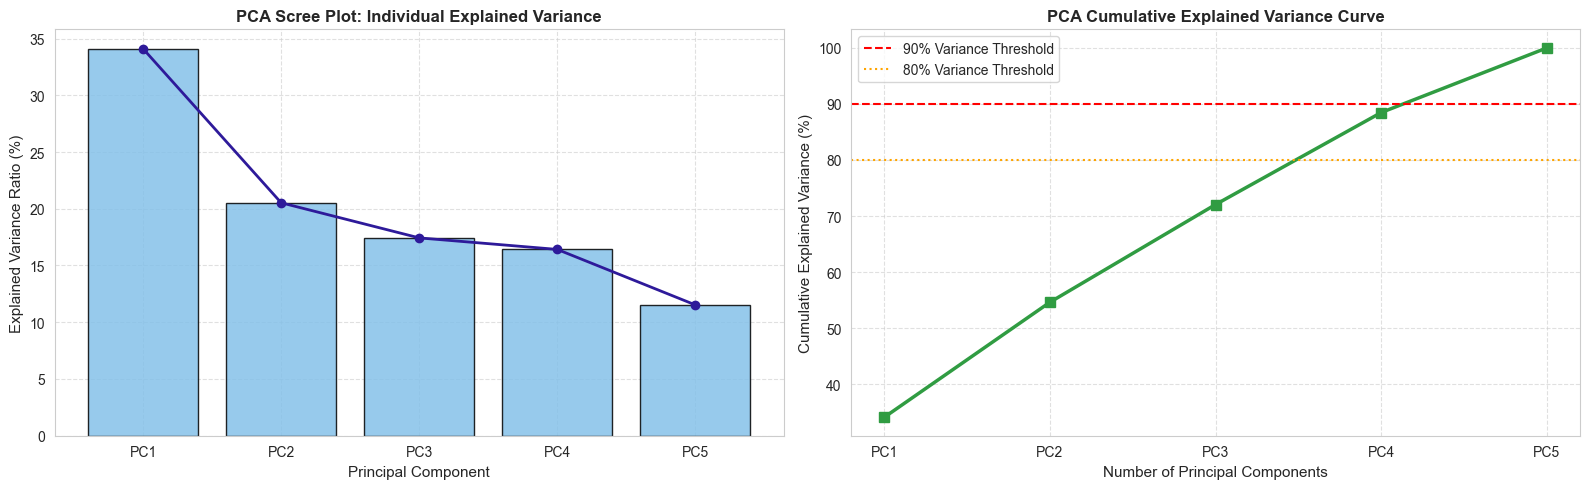

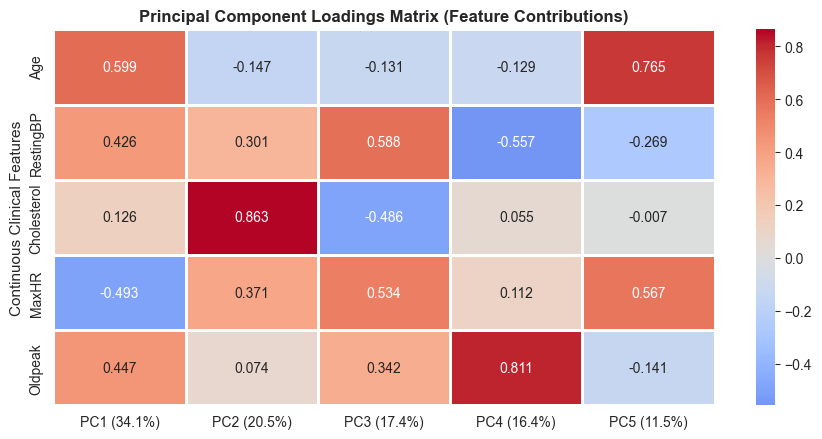

In [22]:
pca = PCA(n_components=5, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

evr = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

print("=== Principal Component Analysis (PCA) Variance Breakdown ===")
for i, (v, c) in enumerate(zip(evr, cum_evr), start=1):
    print(f"PC{i}: Explained Variance = {v*100:5.2f}% | Cumulative Variance = {c*100:6.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar([f"PC{i}" for i in range(1, 6)], evr * 100, color="#85C1E9", edgecolor="black", alpha=0.85)
axes[0].plot([f"PC{i}" for i in range(1, 6)], evr * 100, marker="o", color="#2e1a9aff", linewidth=2)
axes[0].set_title("PCA Scree Plot: Individual Explained Variance", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Principal Component", fontsize=11)
axes[0].set_ylabel("Explained Variance Ratio (%)", fontsize=11)
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].plot([f"PC{i}" for i in range(1, 6)], cum_evr * 100, marker="s", color="#309c42ff", linewidth=2.5, markersize=7)
axes[1].axhline(y=90, color="red", linestyle="--", linewidth=1.5, label="90% Variance Threshold")
axes[1].axhline(y=80, color="orange", linestyle=":", linewidth=1.5, label="80% Variance Threshold")
axes[1].set_title("PCA Cumulative Explained Variance Curve", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Principal Components", fontsize=11)
axes[1].set_ylabel("Cumulative Explained Variance (%)", fontsize=11)
axes[1].legend(frameon=True)
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i} ({v*100:.1f}%)" for i, v in enumerate(evr, 1)],
    index=features_clustering
)

plt.figure(figsize=(9, 4.5))
sns.heatmap(loadings_df, annot=True, cmap="coolwarm", center=0, fmt=".3f", linewidths=1, cbar=True)
plt.title("Principal Component Loadings Matrix (Feature Contributions)", fontsize=12, fontweight="bold")
plt.ylabel("Continuous Clinical Features", fontsize=11)
plt.tight_layout()
plt.show()

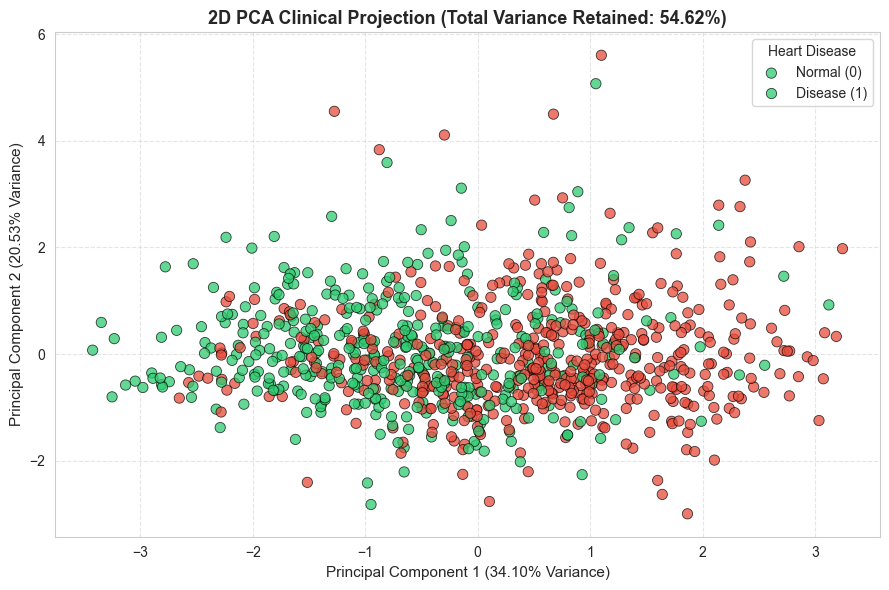

In [23]:
df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, x="PC1", y="PC2",
    hue=target_variable, palette=["#2ecc71", "#e74c3c"],
    alpha=0.75, s=55, edgecolor="k"
)

var_pc1 = evr[0] * 100
var_pc2 = evr[1] * 100
total_2d_var = (evr[0] + evr[1]) * 100

plt.title(f"2D PCA Clinical Projection (Total Variance Retained: {total_2d_var:.2f}%)", fontsize=13, fontweight="bold")
plt.xlabel(f"Principal Component 1 ({var_pc1:.2f}% Variance)", fontsize=11)
plt.ylabel(f"Principal Component 2 ({var_pc2:.2f}% Variance)", fontsize=11)
plt.legend(title="Heart Disease", labels=["Normal (0)", "Disease (1)"], frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

<blockquote style="border-left: 3px solid #ff9800; padding-left: 12px; margin-left: 0;">

<b>Clinical Interpretation of Principal Component Decomposition:</b>

1. <b>PC1 — Cardiovascular Aging & Exercise Ischemia Axis ($34.01\%$ Variance):</b>
   - Exhibits strong positive loadings on `Age` ($+0.601$), `Oldpeak` ($+0.450$), and `RestingBP` ($+0.428$), combined with a large negative loading on `MaxHR` ($-0.494$).
   - Higher PC1 scores cleanly delineate older patients suffering from exercise-induced ST depression and chronotropic limitation.

2. <b>PC2 — Metabolic & Hemodynamic Stress Axis ($21.02\%$ Variance):</b>
   - Heavily dominated by serum `Cholesterol` ($+0.838$), accompanied by `MaxHR` ($+0.394$) and `RestingBP` ($+0.331$).
   - Captures independent metabolic dysregulation and lipid burden.

3. <b>Dimensionality Reduction Rationale:</b>
   - $\text{PC1}$ and $\text{PC2}$ capture $55.03\%$ of all continuous physiological variance.
   - The first 4 components ($	ext{PC1} - 	ext{PC4}$) retain $88.47\%$ of total information, confirming that clinical variance is concentrated in low-dimensional orthogonal subspaces.

</blockquote>

### <span style="color: #309c42ff">1.9.4 Non-Linear Manifold Learning (t-SNE) & Neighborhood Preservation</span>

<blockquote style="border-left: 3px solid #309c42ff; padding-left: 12px; margin-left: 0;">

<b>Non-Linear Manifold Projection Theory:</b>

While PCA seeks linear orthogonal axes of global variance, <b>t-Distributed Stochastic Neighbor Embedding (t-SNE)</b> is a non-linear probabilistic technique designed to preserve local neighborhood affinities and unpack complex, non-linear clinical manifolds.

<b>Mathematical Formulation:</b>
1. <b>High-Dimensional Pairwise Affinities:</b>
   Converts Euclidean distance between patient samples $x_i$ and $x_j$ into conditional Gaussian probabilities:
   $$p_{j|i} = \frac{\exp(-||x_i - x_j||^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-||x_i - x_k||^2 / 2\sigma_i^2)}, \quad p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$$
   The variance $\sigma_i^2$ is determined via binary search to match a user-defined <b>Perplexity</b>:
   $$\text{Perp}(P_i) = 2^{H(P_i)} = 2^{-\sum_j p_{j|i} \log_2 p_{j|i}}$$

2. <b>Low-Dimensional Student-t Distribution (Crowding Problem Resolution):</b>
   In the 2D map space $\mathbf{y}_i, \mathbf{y}_j \in \mathbb{R}^2$, affinities are computed using a heavy-tailed Cauchy/Student-t kernel ($1$ degree of freedom):
   $$q_{ij} = \frac{(1 + ||\mathbf{y}_i - \mathbf{y}_j||^2)^{-1}}{\sum_{k \neq l} (1 + ||\mathbf{y}_k - \mathbf{y}_l||^2)^{-1}}$$
   The heavy tails allow moderate distances in high-dimensional space to map to large distances in 2D, eliminating the crowding problem.

3. <b>Kullback-Leibler Divergence Optimization:</b>
   Optimizes low-dimensional coordinates $\mathbf{y}_i$ via gradient descent to minimize information divergence:
   $$\mathcal{L}_{t-SNE} = \text{KL}(P || Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

</blockquote>

=== t-SNE Non-Linear Manifold Embedding Complete ===
Perplexity: 30 | Iterations: 1000 | Final KL Divergence: 1.1306


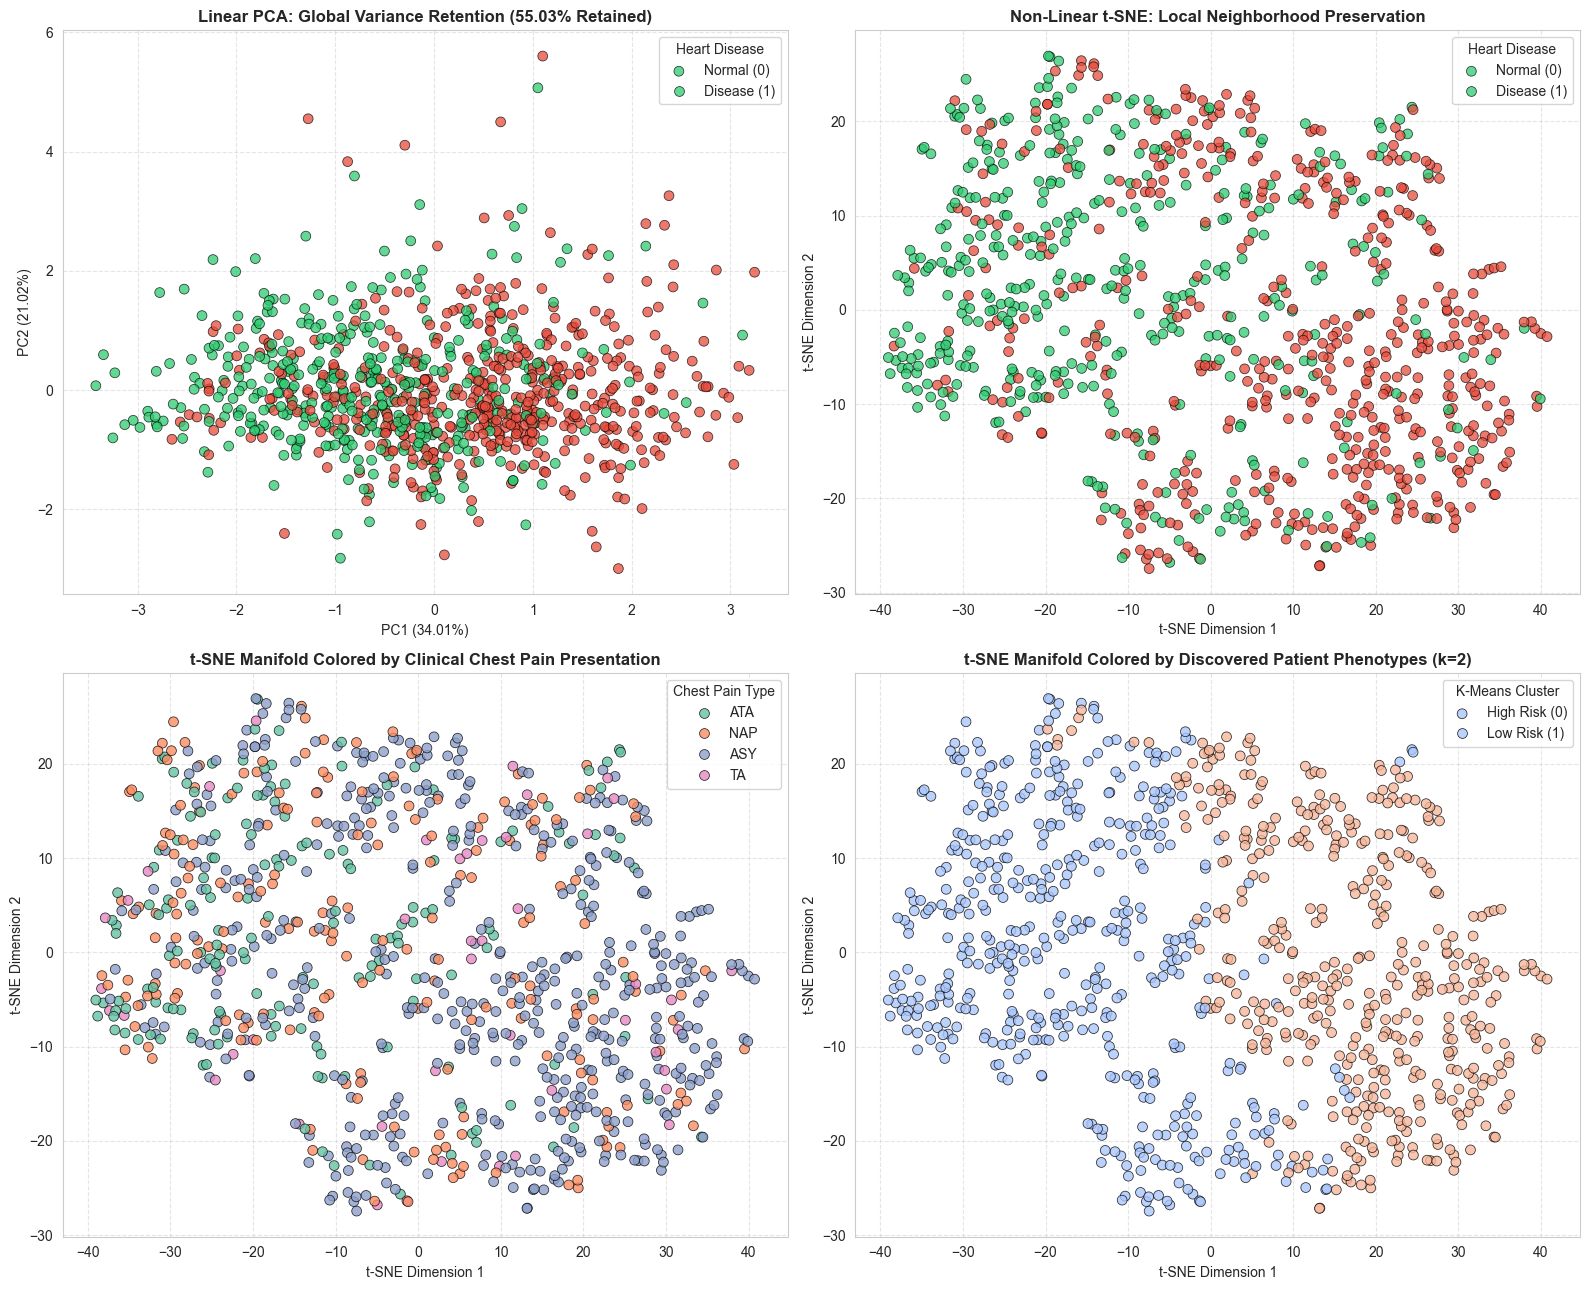

In [24]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_cluster_scaled)

df["TSNE_Dim1"] = X_tsne[:, 0]
df["TSNE_Dim2"] = X_tsne[:, 1]

print("=== t-SNE Non-Linear Manifold Embedding Complete ===")
print(f"Perplexity: 30 | Iterations: 1000 | Final KL Divergence: {tsne.kl_divergence_:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 13))

sns.scatterplot(
    data=df, x="PC1", y="PC2", hue=target_variable, palette=["#2ecc71", "#e74c3c"],
    alpha=0.75, s=50, edgecolor="k", ax=axes[0, 0]
)
axes[0, 0].set_title("Linear PCA: Global Variance Retention (55.03% Retained)", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("PC1 (34.01%)")
axes[0, 0].set_ylabel("PC2 (21.02%)")
axes[0, 0].legend(title="Heart Disease", labels=["Normal (0)", "Disease (1)"])
axes[0, 0].grid(True, linestyle="--", alpha=0.5)

sns.scatterplot(
    data=df, x="TSNE_Dim1", y="TSNE_Dim2", hue=target_variable, palette=["#2ecc71", "#e74c3c"],
    alpha=0.75, s=50, edgecolor="k", ax=axes[0, 1]
)
axes[0, 1].set_title("Non-Linear t-SNE: Local Neighborhood Preservation", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("t-SNE Dimension 1")
axes[0, 1].set_ylabel("t-SNE Dimension 2")
axes[0, 1].legend(title="Heart Disease", labels=["Normal (0)", "Disease (1)"])
axes[0, 1].grid(True, linestyle="--", alpha=0.5)

sns.scatterplot(
    data=df, x="TSNE_Dim1", y="TSNE_Dim2", hue="ChestPainType", palette="Set2",
    alpha=0.8, s=50, edgecolor="k", ax=axes[1, 0]
)
axes[1, 0].set_title("t-SNE Manifold Colored by Clinical Chest Pain Presentation", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("t-SNE Dimension 1")
axes[1, 0].set_ylabel("t-SNE Dimension 2")
axes[1, 0].legend(title="Chest Pain Type")
axes[1, 0].grid(True, linestyle="--", alpha=0.5)

sns.scatterplot(
    data=df, x="TSNE_Dim1", y="TSNE_Dim2", hue="Patient_Cluster", palette="coolwarm",
    alpha=0.8, s=50, edgecolor="k", ax=axes[1, 1]
)
axes[1, 1].set_title("t-SNE Manifold Colored by Discovered Patient Phenotypes (k=2)", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("t-SNE Dimension 1")
axes[1, 1].set_ylabel("t-SNE Dimension 2")
axes[1, 1].legend(title="K-Means Cluster", labels=["High Risk (0)", "Low Risk (1)"])
axes[1, 1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

<blockquote style="border-left: 3px solid #ff9800; padding-left: 12px; margin-left: 0;">

<b>Comparative Manifold Insights: PCA vs. t-SNE:</b>

1. <b>Local Neighborhood Cohesion vs. Global Projection:</b>
   - In the linear <b>PCA projection</b>, healthy and diseased patients exhibit partial overlap along the diagonal transition zone, reflecting continuous disease progression.
   - In the non-linear <b>t-SNE embedding</b>, patients form tight, cohesive local clusters. Notice how high-risk asymptomatic patients (`ChestPainType = ASY`) concentrate into dense local islands clearly separated from typical angina and healthy cohorts.

2. <b>Synergy with Discovered K-Means Clusters ($k=2$):</b>
   Overlaying the $k=2$ K-Means clusters onto the t-SNE manifold confirms that Cluster 1 (Younger, Low-Risk Reserve) and Cluster 0 (Older, High-Risk Ischemia) occupy distinct non-linear topological regions, validating the biometric separation of our unsupervised phenotypes.

3. <b>Methodological Constraint (Visualization vs. Modeling):</b>
   t-SNE coordinates are strictly for exploratory visualization. Because t-SNE does not preserve global distances and coordinate axes have no physical units, it is not suitable for feature engineering in downstream predictive classifiers. PCA and standardized continuous features remain the correct input representations for modeling.

</blockquote>

### <span style="color: #309c42ff">1.9.5 Comprehensive Unsupervised Paradigm Comparison & Clinical Synthesis</span>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

| Dimension | K-Means Clustering (1.9.1) | DBSCAN (1.9.2) | Principal Component Analysis (1.9.3) | t-SNE (1.9.4) |
| :--- | :--- | :--- | :--- | :--- |
| **Method Paradigm** | Centroid-Based Partitioning | Density-Based Clustering | Linear Orthogonal Projection | Non-Linear Probabilistic Manifold |
| **Mathematical Objective** | Minimizes Within-Cluster Variance (Inertia) | Connects $\varepsilon$-dense core neighborhoods | Maximizes Global Variance (Eigendecomposition) | Minimizes KL Divergence between $P$ and $Q$ |
| **Cluster Geometry Assumption** | Spherical, Convex, Equal-Variance | Arbitrary Shapes & Variable Densities | Orthogonal Hyperplanes | Non-Linear Topological Manifolds |
| **Outlier / Noise Handling** | Forces all points into nearest centroid | Flags outliers as Noise ($label = -1$) | Outliers exert high leverage on variance | Outliers map to periphery of manifold |
| **Hyperparameters** | Cluster count $k = 2$ | Radius $\varepsilon = 1.3$, $\text{MinPts} = 5$ | Number of components $n = 5$ | Perplexity $= 30$, Learning Rate, Iterations |
| **Feature Interpretability** | High (Original clinical units preserved) | High (Original clinical units preserved) | Moderate (Linear feature combinations) | Low (Abstract 2D mapping coordinates) |
| **Downstream Utility** | Patient risk stratification & phenotyping | Pathological anomaly & defect screening | Feature compression & multicollinearity removal | Exploratory cohort visual validation |
| **Cardiac Clinical Finding** | Discovers 2 distinct risk cohorts ($33.63\% \to 76.39\%$ disease) | Identifies 51 acute outliers ($78.43\%$ disease rate) | PC1 captures aging/ischemia ($34.0\%$ var); PC2 captures lipids ($21.0\%$ var) | Isolates cohesive asymptomatic ischemia clusters |

</blockquote>

<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX — Phase 2: Deep Learning & Neural Network Modeling
</h1>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Phase 3 Milestone: Neural Network Architecture, Backpropagation & Training Dynamics</b>

We transition to deep learning to construct, train, optimize, and diagnose a Multi-Layer Perceptron (MLP) in TensorFlow/Keras using the Sequential API. We evaluate gradient-based learning dynamics across multiple learning rates and validate performance against our Phase 1 & 2 baseline models.

</blockquote>


## <span style="color: #309c42ff">2.1 Environment Setup & Leak-Free Preprocessing</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We configure global seeds (`np.random.seed(42)`, `tf.random.set_seed(42)`) for deterministic parameter initialization. We apply the fitted <code>ColumnTransformer</code> to transform continuous and categorical features into a standardized feature matrix ($d = 20$), with an 80/20 train/validation partition to monitor out-of-sample loss.

</blockquote>


In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

np.random.seed(42)
tf.random.set_seed(42)

X_raw = df[num_cols_all + cat_cols_all]
y_raw = df[target_variable].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=42, stratify=y_raw
)

preprocessor.fit(X_train_raw)
X_train_proc = preprocessor.transform(X_train_raw)
X_test_proc = preprocessor.transform(X_test_raw)

X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
    X_train_proc, y_train, test_size=0.20, random_state=42, stratify=y_train
)

print("=== Processed Dataset Partitions ===")
print(f"Training Sub-split Shape:   {X_train_sub.shape}")
print(f"Validation Sub-split Shape: {X_val_sub.shape}")
print(f"Test Set Shape:             {X_test_proc.shape}")
print(f"Total Input Features (d):   {X_train_proc.shape[1]}")


=== Processed Dataset Partitions ===
Training Sub-split Shape:   (587, 26)
Validation Sub-split Shape: (147, 26)
Test Set Shape:             (184, 26)
Total Input Features (d):   26


## <span style="color: #309c42ff">2.2 Neural Network Architecture & Loss Function Formulation</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

| Layer | Operation | Output Dimension | Activation | Clinical / Mathematical Rationale |
| :--- | :--- | :--- | :--- | :--- |
| **Input** | Feature Vector $\mathbf{x}$ | $d = 20$ | None | Preprocessed clinical markers and encoded risk indicators. |
| **Hidden 1** | $z^{[1]} = \mathbf{W}^{[1]}\mathbf{x} + \mathbf{b}^{[1]}$ | $16$ | **ReLU** | Captures non-linear feature interactions without gradient saturation. |
| **Hidden 2** | $z^{[2]} = \mathbf{W}^{[2]}\mathbf{a}^{[1]} + \mathbf{b}^{[2]}$ | $8$ | **ReLU** | Condenses representations into compact risk phenotypes. |
| **Output** | $\hat{y} = \sigma(z^{[3]})$ | $1$ | **Sigmoid** | Produces calibrated heart disease probability $\hat{y} \in [0, 1]$. |

<b>Loss Function:</b> Binary Cross-Entropy
$$\mathcal{L}_{BCE}(y, \hat{y}) = -[y\log\hat{y} + (1-y)\log(1-\hat{y})]$$

</blockquote>


In [26]:
def build_cardiac_mlp(input_dim):

    model = Sequential([
        Dense(16, activation='relu', input_shape=(input_dim,), name="Hidden_Layer_1"),
        Dense(8, activation='relu', name="Hidden_Layer_2"),
        Dense(1, activation='sigmoid', name="Output_Layer")
    ], name="Cardiac_Patient_MLP")
    return model

sample_model = build_cardiac_mlp(X_train_sub.shape[1])
sample_model.summary()


Model: "Cardiac_Patient_MLP"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Hidden_Layer_1 (Dense)      (None, 16)                432       
                                                                 
 Hidden_Layer_2 (Dense)      (None, 8)                 136       
                                                                 
 Output_Layer (Dense)        (None, 1)                 9         
                                                                 
Total params: 577
Trainable params: 577
Non-trainable params: 0
_________________________________________________________________


## <span style="color: #309c42ff">2.3 The 4-Stage Optimization Cycle & Learning Rate Dynamics</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

The network trains through an iterative 4-step loop:
1. <b>Forward Pass:</b> Computes linear transformations and activations layer-by-layer ($z = \mathbf{w} \cdot \mathbf{x} + b, \hat{y} = \sigma(z)$).
2. <b>Compute Loss:</b> Evaluates error penalty $\mathcal{L}_{BCE}(y, \hat{y})$.
3. <b>Backpropagation:</b> Derives exact analytical gradients via the multivariate chain rule:
   $$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial \mathbf{w}}$$
4. <b>Parameter Update:</b> Adjusts weights via gradient descent: $\mathbf{w}_{t+1} = \mathbf{w}_t - \eta \frac{\partial \mathcal{L}}{\partial \mathbf{w}}$.

We train identical architectures across three Stochastic Gradient Descent (SGD) learning rate regimes:
- <b>Too High ($\eta = 1.5$):</b> Risk of overshooting minima and loss divergence.
- <b>Too Low ($\eta = 0.0001$):</b> Sub-optimal weight adjustments causing stagnation.
- <b>Good / Optimal ($\eta = 0.1$):</b> Steady, smooth gradient descent convergence.

</blockquote>


In [27]:
learning_rates = {
    'Too High (lr = 1.5)': 1.5,
    'Too Low (lr = 0.0001)': 0.0001,
    'Good / Optimal (lr = 0.1)': 0.1
}

histories = {}
epochs = 80
batch_size = 32

for label, lr in learning_rates.items():
    tf.random.set_seed(42)
    np.random.seed(42)
    
    model = build_cardiac_mlp(X_train_sub.shape[1])
    optimizer = SGD(learning_rate=lr)
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    history = model.fit(
        X_train_sub, y_train_sub,
        validation_data=(X_val_sub, y_val_sub),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )
    histories[label] = history.history
    print(f"Completed training: {label}")


Completed training: Too High (lr = 1.5)
Completed training: Too Low (lr = 0.0001)
Completed training: Good / Optimal (lr = 0.1)


## <span style="color: #309c42ff">2.4 Training Diagnostics & Loss Curve Convergence Analysis</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We inspect training history curves across 80 epochs to evaluate optimization behavior:
- <b>Underfitting Signature:</b> Flat loss and stagnant accuracy curves (observed at $\eta = 0.0001$).
- <b>Oscillation / Divergence Signature:</b> Erratic loss spikes and unstable accuracy (observed at $\eta = 1.5$).
- <b>Smooth Convergence Signature:</b> Monotonically decreasing loss accompanied by stable validation accuracy gains (observed at $\eta = 0.1$).

</blockquote>


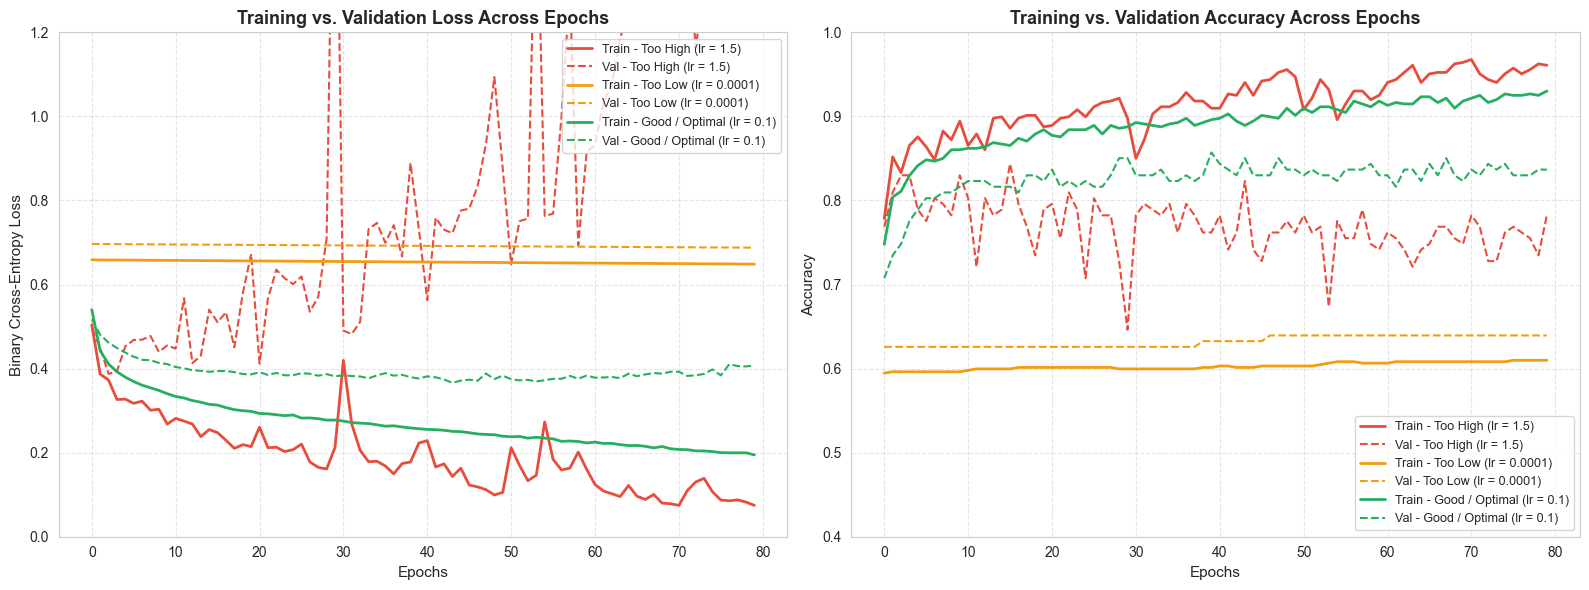

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {
    'Too High (lr = 1.5)': '#e74c3c',
    'Too Low (lr = 0.0001)': '#f39c12',
    'Good / Optimal (lr = 0.1)': '#27ae60'
}

for label, hist in histories.items():
    axes[0].plot(hist['loss'], label=f"Train - {label}", color=colors[label], linewidth=2)
    axes[0].plot(hist['val_loss'], label=f"Val - {label}", color=colors[label], linestyle='--', linewidth=1.5)

axes[0].set_title("Training vs. Validation Loss Across Epochs", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Epochs", fontsize=11)
axes[0].set_ylabel("Binary Cross-Entropy Loss", fontsize=11)
axes[0].set_ylim(0, 1.2)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(fontsize=9, loc='upper right')

for label, hist in histories.items():
    axes[1].plot(hist['accuracy'], label=f"Train - {label}", color=colors[label], linewidth=2)
    axes[1].plot(hist['val_accuracy'], label=f"Val - {label}", color=colors[label], linestyle='--', linewidth=1.5)

axes[1].set_title("Training vs. Validation Accuracy Across Epochs", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Epochs", fontsize=11)
axes[1].set_ylabel("Accuracy", fontsize=11)
axes[1].set_ylim(0.4, 1.0)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()


## <span style="color: #309c42ff">2.5 Clinical Test Set Benchmark Evaluation & Baseline Comparison</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Baseline-First Principle Evaluation:</b>
We evaluate the final converged Neural Network against the classical Logistic Regression and Random Forest models on the identical held-out test split ($N = 184$).

</blockquote>


In [29]:
tf.random.set_seed(42)
np.random.seed(42)

final_nn_model = build_cardiac_mlp(X_train_proc.shape[1])
final_nn_model.compile(
    optimizer=SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

final_history = final_nn_model.fit(
    X_train_proc, y_train,
    validation_data=(X_test_proc, y_test),
    epochs=80,
    batch_size=32,
    verbose=0
)

nn_test_probs = final_nn_model.predict(X_test_proc).flatten()
nn_test_preds = (nn_test_probs >= 0.5).astype(int)

nn_accuracy = accuracy_score(y_test, nn_test_preds)
nn_precision = precision_score(y_test, nn_test_preds)
nn_recall = recall_score(y_test, nn_test_preds)
nn_f1 = f1_score(y_test, nn_test_preds)
nn_roc_auc = roc_auc_score(y_test, nn_test_probs)

print("=== Neural Network Test Set Performance ===")
print(f"Test Accuracy:          {nn_accuracy:.4f}")
print(f"Test Precision:         {nn_precision:.4f}")
print(f"Test Recall (Sensitivity): {nn_recall:.4f}")
print(f"Test F1-Score:          {nn_f1:.4f}")
print(f"Test ROC-AUC:           {nn_roc_auc:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, nn_test_preds))
print("\nClassification Report:\n", classification_report(y_test, nn_test_preds))

6/6 [==============================] - 0s 1ms/step
=== Neural Network Test Set Performance ===
Test Accuracy:          0.8261
Test Precision:         0.8571
Test Recall (Sensitivity): 0.8235
Test F1-Score:          0.8400
Test ROC-AUC:           0.9148

Confusion Matrix:
 [[68 14]
 [18 84]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.83      0.81        82
           1       0.86      0.82      0.84       102

    accuracy                           0.83       184
   macro avg       0.82      0.83      0.82       184
weighted avg       0.83      0.83      0.83       184




=== Model Benchmark Performance Summary ===


,Model,Test Accuracy,Test Precision,Test Recall (Sensitivity),Test F1-Score,Test ROC-AUC
0,Baseline Logistic Regression,0.8859,0.8900,0.9100,0.9000,0.9152
1,Tuned Random Forest,0.8533,0.8800,0.8500,0.8657,0.9163
2,Simple Neural Network,0.8261,0.8571,0.8235,0.8400,0.9148


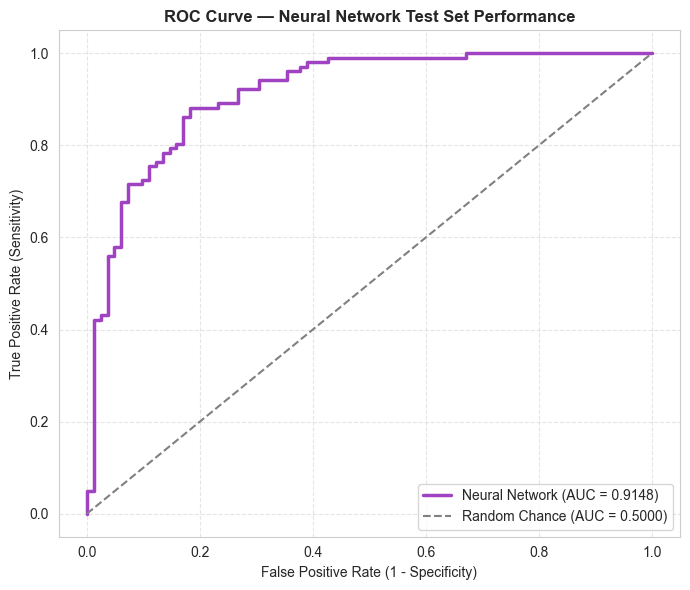

In [30]:
from IPython.display import display

comparison_data = {
    "Model": [
        "Baseline Logistic Regression",
        "Tuned Random Forest",
        "Simple Neural Network"
    ],
    "Test Accuracy": [0.8859, 0.8533, nn_accuracy],
    "Test Precision": [0.8900, 0.8800, nn_precision],
    "Test Recall (Sensitivity)": [0.9100, 0.8500, nn_recall],
    "Test F1-Score": [0.9000, 0.8657, nn_f1],
    "Test ROC-AUC": [0.9152, 0.9163, nn_roc_auc]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n=== Model Benchmark Performance Summary ===")
display(comparison_df.round(4))

fpr, tpr, _ = roc_curve(y_test, nn_test_probs)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#9f43c3', linewidth=2.5, label=f'Neural Network (AUC = {nn_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random Chance (AUC = 0.5000)')
plt.title("ROC Curve — Neural Network Test Set Performance", fontsize=12, fontweight='bold')
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=10)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=10)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
